In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sn
import pickle
import requests 
import sqlite3 
import streamlit

In [ ]:
base_url = "https://api.cellmodelpassports.sanger.ac.uk"
urls= [
        f"{base_url}/models",
        f"{base_url}/genes",
        f"{base_url}/patients",
        f"{base_url}/drugs",
        f"{base_url}/nlmedatapoints"
]

session = requests.session()
param = {
        "page[size]": 500,
}
indicator_data= []
for url in urls:
        response= session.get (url, params = param,  timeout= 180)
        print("url:", response.url)
        print(response.raise_for_status())
        data= response.json()
        print(data)
        print(data["meta"])
        indicator_data.append(data)
        
print(indicator_data[0])
# huge data set hard to work with each individual data set

url: https://api.cellmodelpassports.sanger.ac.uk/models?page%5Bsize%5D=500
None
{'data': [{'attributes': {'cms_prediction': None, 'cnv_available': True, 'comment': None, 'commercial_available': True, 'cris_prediction': None, 'crispr_ko_available': False, 'doi': None, 'drugs_available': False, 'expression_available': True, 'fusions_available': False, 'growth_properties': 'Adherent', 'has_cpv': False, 'methylation_available': False, 'model_treatment': 'Unknown', 'model_type': 'Cell Line', 'mutations_available': True, 'mutations_per_mb': 24.79, 'names': ['PK-59'], 'ploidy': None, 'ploidy_wes': 3.51075116251288, 'ploidy_wgs': None, 'pmed': '7622937.0', 'proteomics_available': False, 'rnaseq_available': True}, 'id': 'SIDM01774', 'links': {'self': '/models/SIDM01774'}, 'relationships': {'analyses': {'data': []}, 'children': {'data': [], 'links': {'related': '/models/parent/SIDM01774'}}, 'files': {'data': [{'id': '21605', 'type': 'file'}, {'id': '41719', 'type': 'file'}, {'id': '21474', 'type

In [6]:
# importing one API at the time with first 1000 records 

base_url = "https://api.cellmodelpassports.sanger.ac.uk"

url_1 = f"{base_url}/models"
url_2 = f"{base_url}/genes"
url_3 = f"{base_url}/patients"
url_4 = f"{base_url}/drugs"
url_5 = f"{base_url}/nlmedatapoints"


params = {"page[size]": 1000,
    
            }

sessions = requests.Session()

    # MODELS
response_model = sessions.get(
            url_1,
             params=params,
            timeout=300
         )
print("URL:", response_model.url)
response_model.raise_for_status()
data_model = response_model.json()
print(data_model)

#GENES
response_genes = sessions.get(
    url_2,
    params=params,
    timeout=300
)
print("URL:", response_genes.url)
response_genes.raise_for_status()
data_genes = response_genes.json()
print(data_genes)

# PATIENTS
response_patients = sessions.get(
    url_3,
    params=params,
    timeout=300
)
print("URL:", response_patients.url)
response_patients.raise_for_status()
data_patients = response_patients.json()
print(data_patients)

# DRUGS
response_drugs = sessions.get(
    url_4,
    params=params,
    timeout=300
)
print("URL:", response_drugs.url)
response_drugs.raise_for_status()
data_drugs = response_drugs.json()
print(data_drugs)

# NLMEDATAPOINTS
response_nlm = sessions.get(
    url_5,
    params=params,
    timeout=300
)
print("URL:", response_nlm.url)
response_nlm.raise_for_status()
data_nlm = response_nlm.json()
print(data_nlm)

URL: https://api.cellmodelpassports.sanger.ac.uk/models?page%5Bsize%5D=1000
{'data': [{'attributes': {'cms_prediction': None, 'cnv_available': True, 'comment': None, 'commercial_available': True, 'cris_prediction': None, 'crispr_ko_available': False, 'doi': None, 'drugs_available': False, 'expression_available': True, 'fusions_available': False, 'growth_properties': 'Adherent', 'has_cpv': False, 'methylation_available': False, 'model_treatment': 'Unknown', 'model_type': 'Cell Line', 'mutations_available': True, 'mutations_per_mb': 24.79, 'names': ['PK-59'], 'ploidy': None, 'ploidy_wes': 3.51075116251288, 'ploidy_wgs': None, 'pmed': '7622937.0', 'proteomics_available': False, 'rnaseq_available': True}, 'id': 'SIDM01774', 'links': {'self': '/models/SIDM01774'}, 'relationships': {'analyses': {'data': []}, 'children': {'data': [], 'links': {'related': '/models/parent/SIDM01774'}}, 'files': {'data': [{'id': '21605', 'type': 'file'}, {'id': '41719', 'type': 'file'}, {'id': '21474', 'type': '

In [ ]:
# get all of the pages for model and gene API 
import math

base_url = "https://api.cellmodelpassports.sanger.ac.uk"
url_1 = f"{base_url}/models"
url_2 = f"{base_url}/genes"
url_3 = f"{base_url}/patients"
url_4 = f"{base_url}/drugs"
url_5 = f"{base_url}/nlmedatapoints"

total_page = data_model["meta"]["count"]/1000
total_page= math.ceil(total_page)
all_model = []

for i in range(1, total_page + 1):

    params = params = {
        "page[size]": 1000,
        "page[number]": i
    }

    response_model = sessions.get(
        url_1,
        params=params,
        timeout=300
    )
    response_model.raise_for_status()
    page_data = response_model.json()
    records = page_data["data"]
    print(f"Page {i}: {len(records)} records")
    all_model.extend(records)
print("Total downloaded:", len(all_model))

# calculating for genes 
total_page = data_genes["meta"]["count"]/1000
total_page= math.ceil(total_page)
all_genes = []

for i in range(1, total_page + 1):

    params = params = {
            "page[size]": 1000,
            "page[number]": i
        }
    
    response_genes = sessions.get(
        url_2,
        params=params,
        timeout=300
    )
    response_genes.raise_for_status()
    page_data = response_genes.json()
    records = page_data["data"]
    print(f"Page {i}: {len(records)} records")
    all_genes.extend(records)
print("Total downloaded:", len(all_genes))




Page 1: 1000 records
Page 2: 1000 records
Page 3: 266 records
Total downloaded: 2266
Page 1: 1000 records
Page 2: 1000 records
Page 3: 1000 records
Page 4: 1000 records
Page 5: 1000 records
Page 6: 1000 records
Page 7: 1000 records
Page 8: 1000 records
Page 9: 1000 records
Page 10: 1000 records
Page 11: 1000 records
Page 12: 1000 records
Page 13: 1000 records
Page 14: 1000 records
Page 15: 1000 records
Page 16: 1000 records
Page 17: 1000 records
Page 18: 1000 records
Page 19: 1000 records
Page 20: 1000 records
Page 21: 1000 records
Page 22: 1000 records
Page 23: 1000 records
Page 24: 1000 records
Page 25: 1000 records
Page 26: 1000 records
Page 27: 1000 records
Page 28: 1000 records
Page 29: 1000 records
Page 30: 1000 records
Page 31: 1000 records
Page 32: 1000 records
Page 33: 1000 records
Page 34: 1000 records
Page 35: 1000 records
Page 36: 1000 records
Page 37: 1000 records
Page 38: 1000 records
Page 39: 1000 records
Page 40: 1000 records
Page 41: 1000 records
Page 42: 1000 records


In [ ]:
# all pages for patients and drug API 
total_page = data_patients["meta"]["count"]/1000
total_page= math.ceil(total_page)
all_patients = []

for i in range(1, total_page + 1):

    params = params = {
        "page[size]": 1000,
        "page[number]": i
    }

    response_patients = sessions.get(
        url_3,
        params=params,
        timeout=300
    )
    response_patients.raise_for_status()
    page_data = response_patients.json()
    records = page_data["data"]
    print(f"Page {i}: {len(records)} records")
    all_patients.extend(records)
print("Total downloaded:", len(all_patients))


total_page = data_drugs["meta"]["count"]/1000
total_page= math.ceil(total_page)
all_drugs = []

for i in range(1, total_page + 1):

    params = params = {
        "page[size]": 1000,
        "page[number]": i
    }

    response_patients = sessions.get(
        url_4,
        params=params,
        timeout=300
    )
    response_drugs.raise_for_status()
    page_data = response_drugs.json()
    records = page_data["data"]
    print(f"Page {i}: {len(records)} records")
    all_drugs.extend(records)
print("Total downloaded:", len(all_drugs))




Page 1: 1000 records
Page 2: 931 records
Total downloaded: 1931
Page 1: 1000 records
Page 2: 1000 records
Total downloaded: 2000


In [ ]:
# all pages for for NLMdatapoint API 
total_page = data_nlm["meta"]["count"]/1000
total_page= math.ceil(total_page)
all_nlms = []

for i in range(1, total_page + 1):

    params = params = {
        "page[size]": 1000,
        "page[number]": i
    }

    response_nlm = sessions.get(
        url_5,
        params=params,
        timeout=400
    )
    response_nlm.raise_for_status()
    page_data = response_nlm.json()
    records = page_data["data"]
    print(f"Page {i}: {len(records)} records")
    all_nlms.extend(records)
print("Total downloaded:", len(all_nlms))


Page 1: 1000 records
Page 2: 1000 records
Page 3: 1000 records
Page 4: 1000 records
Page 5: 1000 records
Page 6: 1000 records
Page 7: 1000 records
Page 8: 1000 records
Page 9: 1000 records
Page 10: 1000 records
Page 11: 1000 records
Page 12: 1000 records
Page 13: 1000 records
Page 14: 1000 records
Page 15: 1000 records
Page 16: 1000 records
Page 17: 1000 records
Page 18: 1000 records
Page 19: 1000 records
Page 20: 1000 records
Page 21: 1000 records
Page 22: 1000 records
Page 23: 1000 records
Page 24: 1000 records
Page 25: 1000 records
Page 26: 1000 records
Page 27: 1000 records
Page 28: 1000 records
Page 29: 1000 records
Page 30: 1000 records
Page 31: 1000 records
Page 32: 1000 records
Page 33: 1000 records
Page 34: 1000 records
Page 35: 1000 records
Page 36: 1000 records
Page 37: 1000 records
Page 38: 1000 records
Page 39: 1000 records
Page 40: 1000 records
Page 41: 1000 records
Page 42: 1000 records
Page 43: 1000 records
Page 44: 1000 records
Page 45: 1000 records
Page 46: 1000 recor

In [4]:
print(data_model.keys())
print(data_model["meta"])
print(type(all_model))
print(len(all_model))
print(type(all_model))
print(len(all_model[0]))
print("---------------")

models_df = pd.json_normalize(all_model)

print(models_df.shape)
print(models_df.head())

dict_keys(['data', 'jsonapi', 'links', 'meta'])
{'count': 2266}
<class 'list'>
2266
<class 'list'>
5
---------------
(2266, 43)
          id   type attributes.cms_prediction  attributes.cnv_available  \
0  SIDM01774  model                       NaN                      True   
1  SIDM00192  model                       NaN                      True   
2  SIDM01447  model                       NaN                      True   
3  SIDM01554  model                       NaN                      True   
4  SIDM01689  model                       NaN                      True   

  attributes.comment attributes.commercial_available  \
0                NaN                            True   
1                                               True   
2                NaN                            True   
3                NaN                            True   
4                NaN                            True   

  attributes.cris_prediction  attributes.crispr_ko_available  \
0                   

In [ ]:
print(models_df.columns)
models_df.to_csv("all_models_df.csv", index=False)
print(models_df["attributes.model_type"].nunique())
print(models_df["attributes.model_type"].value_counts())

Index(['id', 'type', 'attributes.cms_prediction', 'attributes.cnv_available',
       'attributes.comment', 'attributes.commercial_available',
       'attributes.cris_prediction', 'attributes.crispr_ko_available',
       'attributes.doi', 'attributes.drugs_available',
       'attributes.expression_available', 'attributes.fusions_available',
       'attributes.growth_properties', 'attributes.has_cpv',
       'attributes.methylation_available', 'attributes.model_treatment',
       'attributes.model_type', 'attributes.mutations_available',
       'attributes.mutations_per_mb', 'attributes.names', 'attributes.ploidy',
       'attributes.ploidy_wes', 'attributes.ploidy_wgs', 'attributes.pmed',
       'attributes.proteomics_available', 'attributes.rnaseq_available',
       'links.self', 'relationships.analyses.data',
       'relationships.children.data', 'relationships.children.links.related',
       'relationships.files.data', 'relationships.files.links.related',
       'relationships.growth

In [10]:
selected_models_df_CSV= pd.read_csv("C:/Users/e_bab/Documents/4geeks/final_project/sanger project/all_models_df.csv")

In [11]:
columns = ["id",
    "attributes.model_type",
    "attributes.names",
    "attributes.expression_available",
    "attributes.rnaseq_available",
    "attributes.mutations_available",
    "attributes.drugs_available",
    ]
# selected_models_df= models_df[columns]
selected_models_df=selected_models_df_CSV[columns]
print(selected_models_df.head(3))
print(selected_models_df["attributes.expression_available"].value_counts())
print(selected_models_df["attributes.rnaseq_available"].value_counts())

          id attributes.model_type attributes.names  \
0  SIDM01774             Cell Line        ['PK-59']   
1  SIDM00192             Cell Line     ['SNU-1033']   
2  SIDM01447             Cell Line      ['SNU-466']   

   attributes.expression_available  attributes.rnaseq_available  \
0                             True                         True   
1                             True                         True   
2                             True                         True   

   attributes.mutations_available  attributes.drugs_available  
0                            True                       False  
1                            True                       False  
2                            True                       False  
attributes.expression_available
True     1970
False     296
Name: count, dtype: int64
attributes.rnaseq_available
True     1921
False     345
Name: count, dtype: int64


In [12]:
print(selected_models_df.shape)
print("Duplicate model IDs:",
      selected_models_df["id"].duplicated().sum())
print("\nMissing values:")
print(selected_models_df.isna().sum())

(2266, 7)
Duplicate model IDs: 0

Missing values:
id                                 0
attributes.model_type              0
attributes.names                   0
attributes.expression_available    0
attributes.rnaseq_available        0
attributes.mutations_available     0
attributes.drugs_available         0
dtype: int64


In [13]:
print(data_genes.keys())
print(data_genes["meta"])
print(type(all_genes))
print(len(all_genes))
print(len(all_genes[0]))
print("-----------")
genes_df= pd.json_normalize(all_genes)

print(genes_df.shape)
print(genes_df.head())

dict_keys(['data', 'jsonapi', 'links', 'meta'])
{'count': 45751}
<class 'list'>
45751
4
-----------
(45751, 19)
          id  type  attributes.cancer_driver attributes.hgnc_id  \
0  SIDG74502  gene                     False         HGNC:55700   
1  SIDG74503  gene                     False         HGNC:56934   
2  SIDG74504  gene                     False         HGNC:55520   
3  SIDG74505  gene                     False         HGNC:56156   
4  SIDG74506  gene                     False         HGNC:54662   

  attributes.hgnc_merge_comment attributes.hgnc_status  \
0                           NaN                current   
1                           NaN                current   
2                           NaN                current   
3                           NaN                current   
4                           NaN                current   

   attributes.in_yusa_lib attributes.location attributes.method_of_action  \
0                   False             15q13.2              

In [14]:
print(genes_df.columns)
genes_df.to_csv("All_genes_df.csv", index = False)

Index(['id', 'type', 'attributes.cancer_driver', 'attributes.hgnc_id',
       'attributes.hgnc_merge_comment', 'attributes.hgnc_status',
       'attributes.in_yusa_lib', 'attributes.location',
       'attributes.method_of_action', 'attributes.symbol',
       'attributes.tumour_suppressor',
       'relationships.essentiality_profiles.data',
       'relationships.essentiality_profiles.links.related',
       'relationships.gene_families.data', 'relationships.identifiers.data',
       'relationships.l0.data', 'relationships.l1.data',
       'relationships.l2.data', 'relationships.names.data'],
      dtype='str')


In [15]:
gene_columns = [
    "id",
    "type",
    "attributes.cancer_driver",
    "attributes.hgnc_id",
    "attributes.symbol",
    "attributes.tumour_suppressor"
]
gene_select_df= genes_df[gene_columns]
print(gene_select_df.head(3))
print(gene_select_df[["attributes.cancer_driver","attributes.tumour_suppressor"]].apply(pd.Series.value_counts))
genes_df[["attributes.cancer_driver", "attributes.tumour_suppressor"]].apply(
    pd.Series.value_counts, dropna=False
)

          id  type  attributes.cancer_driver attributes.hgnc_id  \
0  SIDG74502  gene                     False         HGNC:55700   
1  SIDG74503  gene                     False         HGNC:56934   
2  SIDG74504  gene                     False         HGNC:55520   

  attributes.symbol attributes.tumour_suppressor  
0           WHAMMP4                        False  
1            WTAPP2                        False  
2          WWP1-AS1                        False  
       attributes.cancer_driver  attributes.tumour_suppressor
False                     44960                        3273.0
True                        791                           NaN


,attributes.cancer_driver,attributes.tumour_suppressor
False,44960.0,3273.0
True,791.0,NaN
None,NaN,42478.0


In [16]:
gene_columns = [
    "id",
    "type",
    "attributes.hgnc_id",
    "attributes.symbol",
]
gene_model_df= genes_df[gene_columns]
print(gene_model_df.head(3))
print(gene_model_df["type"].nunique())
print(gene_model_df["type"].value_counts())


          id  type attributes.hgnc_id attributes.symbol
0  SIDG74502  gene         HGNC:55700           WHAMMP4
1  SIDG74503  gene         HGNC:56934            WTAPP2
2  SIDG74504  gene         HGNC:55520          WWP1-AS1
1
type
gene    45751
Name: count, dtype: int64


In [17]:
genes_models_df_CSV= pd.read_csv("C:/Users/e_bab/Documents/4geeks/final_project/sanger project/all_genes_df.csv")
gene_columns_csv = [
    "id",
    "attributes.hgnc_id",
    "attributes.symbol"]
genes_models_select= genes_models_df_CSV[gene_columns_csv]

In [18]:
print(genes_models_df_CSV.head(3))

          id  type  attributes.cancer_driver attributes.hgnc_id  \
0  SIDG74502  gene                     False         HGNC:55700   
1  SIDG74503  gene                     False         HGNC:56934   
2  SIDG74504  gene                     False         HGNC:55520   

  attributes.hgnc_merge_comment attributes.hgnc_status  \
0                           NaN                current   
1                           NaN                current   
2                           NaN                current   

   attributes.in_yusa_lib attributes.location attributes.method_of_action  \
0                   False             15q13.2                         NaN   
1                   False              6p12.3                         NaN   
2                   False              8q21.3                         NaN   

  attributes.symbol attributes.tumour_suppressor  \
0           WHAMMP4                        False   
1            WTAPP2                        False   
2          WWP1-AS1              

In [19]:
gene_model_df= gene_model_df.drop(columns= "type")

In [20]:
print(gene_model_df.shape)
print("Duplicate rows:",
      gene_model_df.duplicated().sum())
print("\nMissing values:")
print(gene_model_df.isna().sum())

(45751, 3)
Duplicate rows: 0

Missing values:
id                    0
attributes.hgnc_id    0
attributes.symbol     0
dtype: int64


In [53]:
print(data_patients.keys())
print(data_patients["meta"])
print(len(all_patients))
print(type(all_patients))
print(len(all_patients[0]))
print("-----------")
patients_df= pd.json_normalize(all_patients)

print(patients_df.shape)
print(patients_df.head())



dict_keys(['data', 'jsonapi', 'links', 'meta'])
{'count': 1931}
1931
<class 'list'>
5
-----------
(1931, 28)
          id     type  attributes.alcohol_consumption_per_week  \
0  SIDP01857  patient                                      NaN   
1  SIDP01124  patient                                      NaN   
2  SIDP00349  patient                                      NaN   
3  SIDP01102  patient                                      NaN   
4  SIDP01087  patient                                      NaN   

  attributes.alcohol_exposure_intensity  \
0                               Unknown   
1                         Heavy Drinker   
2                                    NA   
3                               Unknown   
4                         Heavy Drinker   

  attributes.colorectal_cancer_risk_factors attributes.diabetes_treatment  \
0                                       NaN                          None   
1                                       NaN                          None   
2   

In [54]:
print(patients_df.columns)
patients_df.to_csv("all_patients_df.csv", index = False)

Index(['id', 'type', 'attributes.alcohol_consumption_per_week',
       'attributes.alcohol_exposure_intensity',
       'attributes.colorectal_cancer_risk_factors',
       'attributes.diabetes_treatment', 'attributes.ethnicity',
       'attributes.family_history_of_cancer',
       'attributes.gastrointestinal_disorder_diagnosed', 'attributes.gender',
       'attributes.h_pylori_infection',
       'attributes.history_clinical_chronic_pancreatitis',
       'attributes.history_diabetes', 'attributes.history_prior_colon_polyps',
       'attributes.history_synchronous_colon_rectal_tumours',
       'attributes.model_relations_comment',
       'attributes.patient_history_of_gastrointestinal_disorder',
       'attributes.previous_current_barretts_oesophagus',
       'attributes.prior_malignancies', 'attributes.prior_other_malignancy',
       'attributes.prior_same_malignancy', 'attributes.reflux_disease_prior',
       'attributes.reflux_disease_treatment', 'attributes.smoking_status',
       'a

In [55]:
p_columns = ["id",
    "type",
    "attributes.alcohol_exposure_intensity",
    "attributes.colorectal_cancer_risk_factors",
    "attributes.diabetes_treatment",
    "attributes.ethnicity",
    "attributes.family_history_of_cancer",
    "attributes.gastrointestinal_disorder_diagnosed",
    "attributes.gender",
    "attributes.h_pylori_infection",
    "attributes.history_clinical_chronic_pancreatitis",
    "attributes.history_diabetes",
    "attributes.history_prior_colon_polyps",
    "attributes.history_synchronous_colon_rectal_tumours",
    "attributes.patient_history_of_gastrointestinal_disorder",
    "attributes.prior_malignancies",
    "attributes.prior_other_malignancy",
    "attributes.smoking_status",
    "attributes.species"
]

patients_df[p_columns].head()
patients_df[p_columns].isna().sum().sort_values(ascending=False)


attributes.diabetes_treatment                              1930
attributes.gastrointestinal_disorder_diagnosed             1930
attributes.history_clinical_chronic_pancreatitis           1922
attributes.history_diabetes                                1922
attributes.h_pylori_infection                              1892
attributes.history_synchronous_colon_rectal_tumours        1871
attributes.colorectal_cancer_risk_factors                  1870
attributes.patient_history_of_gastrointestinal_disorder    1870
attributes.history_prior_colon_polyps                      1870
attributes.prior_other_malignancy                          1824
attributes.family_history_of_cancer                        1823
attributes.alcohol_exposure_intensity                         0
type                                                          0
id                                                            0
attributes.ethnicity                                          0
attributes.gender                       

In [56]:
p_columns_mod = [
    "id",
    "type",
    "attributes.ethnicity",
    "attributes.gender",
    "attributes.prior_malignancies",
    "attributes.smoking_status",
    "attributes.species"
]
patients_df[p_columns_mod].head()


,id,type,attributes.ethnicity,attributes.gender,attributes.prior_malignancies,attributes.smoking_status,attributes.species
0,SIDP01857,patient,White,Female,Yes,Non-Smoker,Homo Sapiens
1,SIDP01124,patient,White,Male,No,Never-Smoked,Homo Sapiens
2,SIDP00349,patient,White,Female,Unknown,Unknown,Homo Sapiens
3,SIDP01102,patient,Unknown,Male,No,Non-Smoker,Homo Sapiens
4,SIDP01087,patient,White,Male,No,Smoker,Homo Sapiens


In [57]:
for col in p_columns_mod:
    print(f" {col} : {patients_df[col].value_counts(dropna=False)}")
    print("----------------")

 id : id
SIDP01857    1
SIDP01124    1
SIDP00349    1
SIDP01102    1
SIDP01087    1
            ..
SIDP02038    1
SIDP02039    1
SIDP02040    1
SIDP02042    1
SIDP02041    1
Name: count, Length: 1931, dtype: int64
----------------
 type : type
patient    1931
Name: count, dtype: int64
----------------
 attributes.ethnicity : attributes.ethnicity
Unknown        923
White          652
East Asian     286
Black           42
South Asian     18
Other            9
Arabic           1
Name: count, dtype: int64
----------------
 attributes.gender : attributes.gender
Male       1009
Female      717
Unknown     205
Name: count, dtype: int64
----------------
 attributes.prior_malignancies : attributes.prior_malignancies
Unknown    1824
No           92
Yes          15
Name: count, dtype: int64
----------------
 attributes.smoking_status : attributes.smoking_status
Unknown         1704
Smoker            87
Ex-Smoker         80
Never-Smoked      31
Non-Smoker        29
Name: count, dtype: int64
------

In [58]:
p_columns_mod2 = [
    "id",
    "attributes.ethnicity",
    "attributes.gender"
]
patient_select = patients_df[p_columns_mod2]



In [21]:
patients_df_CSV= pd.read_csv("C:/Users/e_bab/Documents/4geeks/final_project/sanger project/all_patients_df.csv")
p_columns_mod2 = [
    "id",
    "attributes.ethnicity",
    "attributes.gender"
]
patients_models_select= patients_df_CSV[p_columns_mod2]

In [59]:
print(patient_select.shape)
print("Duplicate rows:",
      patient_select.duplicated().sum())
print("\nMissing values:")
print(patient_select.isna().sum())

(1931, 3)
Duplicate rows: 0

Missing values:
id                      0
attributes.ethnicity    0
attributes.gender       0
dtype: int64


In [60]:
print(data_drugs.keys())
print(data_drugs["meta"])
print(type(all_drugs))
print(len(all_drugs[0]))
print(len(all_drugs))
print("-----------")
drugs_df= pd.json_normalize(all_drugs)

print(drugs_df.shape)
print(drugs_df.head())

dict_keys(['data', 'jsonapi', 'links', 'meta'])
{'count': 1062}
<class 'list'>
5
2000
-----------
(2000, 17)
     id  type attributes.chembl  attributes.company_id  \
0  2112  drug               NaN                   1055   
1  2113  drug               NaN                   1055   
2  2145  drug               NaN                   1083   
3  2149  drug               NaN                   1050   
4  2360  drug              None                   1095   

     attributes.date_created    attributes.date_updated attributes.drug_name  \
0  2023-10-27T00:00:00+00:00  2023-10-29T00:00:00+00:00                VTP-A   
1  2023-10-27T00:00:00+00:00  2023-10-29T00:00:00+00:00                VTP-B   
2  2023-10-27T00:00:00+00:00  2023-10-29T00:00:00+00:00              PBD-288   
3  2023-10-27T00:00:00+00:00  2023-10-29T00:00:00+00:00             CT7033-2   
4  2023-10-27T00:00:00+00:00  2023-10-29T00:00:00+00:00              THR-101   

  attributes.drug_target_pathway attributes.inchi_key attribu

In [61]:
print(drugs_df.columns)
drugs_df.to_csv("all_drugs_df.csv", index = False)

Index(['id', 'type', 'attributes.chembl', 'attributes.company_id',
       'attributes.date_created', 'attributes.date_updated',
       'attributes.drug_name', 'attributes.drug_target_pathway',
       'attributes.inchi_key', 'attributes.pubchem',
       'attributes.putative_target', 'attributes.screening_site',
       'attributes.synonyms', 'attributes.webrelease', 'links.self',
       'relationships.ic50s.data', 'relationships.ic50s.links.related'],
      dtype='str')


In [62]:
d_columns= ["id","attributes.drug_name","attributes.drug_target_pathway"]
for col in d_columns :
    print(f" col: {drugs_df[col].value_counts()}")

 col: id
2112    2
2113    2
2145    2
2149    2
2360    2
       ..
2040    2
2043    2
2044    2
2045    2
2046    2
Name: count, Length: 1000, dtype: int64
 col: attributes.drug_name
Gemcitabine     6
UNC0638         6
Selumetinib     6
AZD4547         6
Fulvestrant     6
               ..
AGK2            2
BIBR-1532       2
Pyridostatin    2
AMG-319         2
MK-8776         2
Name: count, Length: 925, dtype: int64
 col: attributes.drug_target_pathway
Other                                272
Other, kinases                       258
RTK signaling                        168
PI3K/MTOR signaling                  140
Cell cycle                           110
Genome integrity                     108
ERK MAPK signaling                   102
Apoptosis regulation                  96
Unclassified                          86
DNA replication                       84
Chromatin histone methylation         82
Chromatin histone acetylation         72
EGFR signaling                        60
Mitosis

In [63]:
drugs_df_CSV= pd.read_csv("C:/Users/e_bab/Documents/4geeks/final_project/sanger project/all_drugs_df.csv")
d_columns= ["id","attributes.drug_name","attributes.drug_target_pathway"]
drug_select_df= drugs_df_CSV[d_columns]

In [64]:
drug_select = drugs_df[d_columns]

In [ ]:
print(data_nlm.keys())
print(data_nlm["meta"])
print(type(all_nlms))
print(len(all_nlms[0]))
print(len(all_nlms))
print("-----------")
nlm_df= pd.json_normalize(all_nlms)

print(nlm_df.shape)
print(nlm_df.head())

dict_keys(['data', 'jsonapi', 'links', 'meta'])
{'count': 4372470}
<class 'list'>
4
4372470
-----------
(4372470, 11)
        id             type  attributes.nlme_curve_id  attributes.position  \
0  1314996  nlme_datapoints                    243467                 1028   
1  1314997  nlme_datapoints                    243467                  365   
2  1314998  nlme_datapoints                    243467                  491   
3  1314999  nlme_datapoints                    243467                 1430   
4  1315000  nlme_datapoints                    243467                  509   

   attributes.scan_id  attributes.x_micromolar  attributes.xval  \
0               53055                      2.0              9.0   
1               53055                      2.0              9.0   
2               53055                      2.0              9.0   
3               53055                      2.0              9.0   
4               53055                      2.0              9.0   

   attribu

In [ ]:
print(nlm_df.columns)
nlm_df.to_csv("all_nlm_df.csv", index = False)

Index(['id', 'type', 'attributes.nlme_curve_id', 'attributes.position',
       'attributes.scan_id', 'attributes.x_micromolar', 'attributes.xval',
       'attributes.yhat', 'attributes.yres', 'attributes.yval', 'links.self'],
      dtype='str')


In [ ]:
nlm_columns = [
    "id",
    "attributes.nlme_curve_id",
    "attributes.scan_id",
    "attributes.position",
    "attributes.xval",
    "attributes.yhat",
    "attributes.yres",
    "attributes.yval"
]
print(nlm_df["attributes.scan_id"].isna().sum())
print(nlm_df["attributes.scan_id"].nunique())

0
19126


In [ ]:
nlm_columns_mod = [
    "id",
    "attributes.nlme_curve_id",
    "attributes.scan_id",
    "attributes.position",
    "attributes.xval",
    "attributes.yhat",
    "attributes.yres",
    "attributes.yval"
]

for col in nlm_columns_mod :
    print(f" col: {nlm_df[col].value_counts()}")

 col: id
1315100    2
1315101    2
1315102    2
1315103    2
1315104    2
          ..
5687419    1
5687420    1
5687421    1
5687422    1
5687423    1
Name: count, Length: 3439724, dtype: int64
 col: attributes.nlme_curve_id
256628    10231
256595    10168
258251     8985
336064     8922
336274     8836
          ...  
475022        6
475189        6
478702        6
478775        6
479355        6
Name: count, Length: 194487, dtype: int64
 col: attributes.scan_id
49991    1090
50644    1083
39739    1058
42311    1040
48085    1040
         ... 
56644       7
56646       7
56647       7
56648       7
56650       7
Name: count, Length: 19126, dtype: int64
 col: attributes.position
137     16124
173     15321
1364    15147
1045    14714
1400    14520
        ...  
560       102
216        92
334        89
1209       79
814        68
Name: count, Length: 1172, dtype: int64
 col: attributes.xval
 9.000000    1021880
-0.965024     385758
 0.695813     337285
 7.339163     305206
 5.678325 

In [ ]:
nlm_df.groupby("attributes.nlme_curve_id")["attributes.scan_id"].nunique()

attributes.nlme_curve_id
243467    14
243468     2
243469     1
243470     1
243471     1
          ..
486922     3
486923     1
486925     1
486928     1
486929     1
Name: attributes.scan_id, Length: 194487, dtype: int64

In [ ]:
print(nlm_df[nlm_columns_mod].shape)
print("Duplicate rows:",
      nlm_df[nlm_columns_mod].duplicated().sum())
print("\nMissing values:")
print(nlm_df[nlm_columns_mod].isna().sum())

(4372470, 8)
Duplicate rows: 932746

Missing values:
id                          0
attributes.nlme_curve_id    0
attributes.scan_id          0
attributes.position         0
attributes.xval             0
attributes.yhat             0
attributes.yres             0
attributes.yval             0
dtype: int64


In [ ]:
# checking duplicate with "id"
print(nlm_df["id"].duplicated().sum())
dup_id = nlm_df["id"].duplicated(keep= False)
check_dub = nlm_df[dup_id].groupby("id")[nlm_columns_mod].nunique()
print(check_dub.max())



932746
id                          1
attributes.nlme_curve_id    1
attributes.scan_id          1
attributes.position         1
attributes.xval             1
attributes.yhat             1
attributes.yres             1
attributes.yval             1
dtype: int64


In [65]:
nlms_df_CSV= pd.read_csv("C:/Users/e_bab/Documents/4geeks/final_project/sanger project/all_nlm_df.csv")
nlm_columns_mod = [
    "id",
    "attributes.nlme_curve_id",
    "attributes.scan_id",
    "attributes.position",
    "attributes.xval",
    "attributes.yhat",
    "attributes.yres",
    "attributes.yval"
]
nlm_select_df= nlms_df_CSV[nlm_columns_mod].drop_duplicates(subset="id").copy()

In [ ]:

select_nlm= nlm_df[nlm_columns_mod].drop_duplicates(subset="id").copy()
print(select_nlm.shape)
print("Duplicate IDs:", select_nlm["id"].duplicated().sum())

# other data points 

In [25]:
sensitivity_data = pd.read_excel("C:/Users/e_bab/Documents/4geeks/final_project/sanger project/GDSC2_fitted_dose_response_27Oct23.xlsx")
print(sensitivity_data.head())
print(sensitivity_data.shape)

  DATASET  NLME_RESULT_ID  NLME_CURVE_ID CELL_LINE_NAME SANGER_MODEL_ID  \
0   GDSC2             343       15946310         PFSK-1       SIDM01132   
1   GDSC2             343       15946548           A673       SIDM00848   
2   GDSC2             343       15946830            ES5       SIDM00263   
3   GDSC2             343       15947087            ES7       SIDM00269   
4   GDSC2             343       15947369          EW-11       SIDM00203   

           CANCER_TYPE  DRUG_ID     DRUG_NAME PUTATIVE_TARGET  \
0  Other Solid Cancers     1003  Camptothecin            TOP1   
1      Ewing's Sarcoma     1003  Camptothecin            TOP1   
2      Ewing's Sarcoma     1003  Camptothecin            TOP1   
3      Ewing's Sarcoma     1003  Camptothecin            TOP1   
4      Ewing's Sarcoma     1003  Camptothecin            TOP1   

      PATHWAY_NAME  MIN_CONC  MAX_CONC   LN_IC50       AUC      RMSE   Z_SCORE  
0  DNA replication    0.0001       0.1 -1.463887  0.930220  0.089052  0.43312

In [26]:
print(sensitivity_data.duplicated().sum().sum())
print(sensitivity_data.isna().sum())
print(sensitivity_data.isna().mean().mean()*100)


0
DATASET                0
NLME_RESULT_ID         0
NLME_CURVE_ID          0
CELL_LINE_NAME         0
SANGER_MODEL_ID        0
CANCER_TYPE            0
DRUG_ID                0
DRUG_NAME              0
PUTATIVE_TARGET    27155
PATHWAY_NAME           0
MIN_CONC               0
MAX_CONC               0
LN_IC50                0
AUC                    0
RMSE                   0
Z_SCORE                0
dtype: int64
0.7012128361070253


In [27]:
print(sensitivity_data["PUTATIVE_TARGET"].nunique())
sensitivity_data= sensitivity_data.drop(columns ="PUTATIVE_TARGET")
# decide to drop putative target 

185


In [28]:
mutation_summary = pd.read_csv("C:/Users/e_bab/Documents/4geeks/final_project/sanger project/mutations_summary_20260724.csv")
print(mutation_summary.head())
print(mutation_summary.shape)

  gene_symbol  ensembl_gene_id transcript_id     model_name   model_id  \
0       RBM10  ENSG00000182872           NaN  WTSI-COLO_216  SIDM01951   
1      ARID1A  ENSG00000117713           NaN  WTSI-COLO_021  SIDM01268   
2      ARID1A  ENSG00000117713           NaN  WTSI-COLO_021  SIDM01268   
3      ARID1A  ENSG00000117713           NaN  WTSI-COLO_021  SIDM01268   
4      PIK3R1  ENSG00000145675           NaN  WTSI-COLO_021  SIDM01268   

  protein_mutation      rna_mutation     cdna_mutation chromosome  position  \
0          p.Q669*         r.2005c>u         c.2005C>T        NaN       NaN   
1      p.R306fs*57        r.1303delC         c.914delC        NaN       NaN   
2      p.D1850fs*4   r.5930_5931insg   c.5541_5542insG        NaN       NaN   
3     p.D1850fs*34  r.5930_5931insgg  c.5541_5542insGG        NaN       NaN   
4      p.Q153fs*13  r.1034_1035delAC    c.454_455delAC        NaN       NaN   

  reference alternative cancer_driver cancer_predisposition_variant  \
0       N

In [29]:
mutation_columns = [
    "gene_symbol",
    "ensembl_gene_id",
    "transcript_id",
    "model_id",
    "gene_id",
    "protein_mutation",
    "rna_mutation",
    "cdna_mutation",
    "effect",
    "vaf",
    "cancer_driver",
    "cancer_predisposition_variant",
    "found_in_matched_tumour"
]

mutation_selected = mutation_summary[mutation_columns]

In [30]:
print(mutation_selected.duplicated().sum().sum())
print(mutation_selected.isna().sum())
print(mutation_selected.isna().mean().mean()*100)

0
gene_symbol                          0
ensembl_gene_id                      0
transcript_id                      398
model_id                             0
gene_id                              0
protein_mutation                     0
rna_mutation                         0
cdna_mutation                        0
effect                               0
vaf                                  0
cancer_driver                        0
cancer_predisposition_variant        0
found_in_matched_tumour          11961
dtype: int64
6.327403046205042


In [31]:
mutation_selected = mutation_selected.drop(columns=["found_in_matched_tumour"])
print(mutation_selected.isna().sum())
# will keep the transcipt_id

gene_symbol                        0
ensembl_gene_id                    0
transcript_id                    398
model_id                           0
gene_id                            0
protein_mutation                   0
rna_mutation                       0
cdna_mutation                      0
effect                             0
vaf                                0
cancer_driver                      0
cancer_predisposition_variant      0
dtype: int64


In [7]:
expression_data = pd.read_csv("C:/Users/e_bab/Documents/4geeks/final_project/sanger project/rnaseq_merged_rsem_tpm_20260323.csv")
print(expression_data.head())
print(expression_data.shape)

      model_id       Unnamed: 1 Unnamed: 2 SIDM00001 SIDM00002 SIDM00003  \
0   model_name              NaN        NaN     MEC-1   NBsusSR       M14   
1  data_source              NaN        NaN     Broad    Sanger    Sanger   
2  gene_symbol  ensembl_gene_id    gene_id       NaN       NaN       NaN   
3         A1BG  ENSG00000121410  SIDG00001     3.853    4.5059    3.9736   
4     A1BG-AS1  ENSG00000268895  SIDG00002    1.8156    2.3868    3.1408   

       SIDM00005 SIDM00006 SIDM00007 SIDM00008  ...      SIDM02262  \
0  MDA-MB-134-VI     MCC26     MCC13      MCAS  ...  WTSI-COLO_427   
1          Broad    Sanger    Sanger     Broad  ...         Sanger   
2            NaN       NaN       NaN       NaN  ...            NaN   
3         5.7038    3.9069    6.1198    0.0566  ...         0.1635   
4         3.3334    2.5801    3.5336    0.0976  ...              0   

       SIDM02263      SIDM02264        SIDM02265        SIDM02266  \
0  WTSI-COLO_425  WTSI-COLO_061  WTSI-COLIVM_100  WTS

C:\Users\e_bab\AppData\Local\Temp\ipykernel_28956\3322380400.py:1: DtypeWarning: Columns (0: SIDM00001, 1: SIDM00002, 2: SIDM00003, 3: SIDM00005, 4: SIDM00006, 5: SIDM00007, 6: SIDM00008, 7: SIDM00009, 8: SIDM00011, 9: SIDM00014, 10: SIDM00015, 11: SIDM00016, 12: SIDM00017, 13: SIDM00018, 14: SIDM00023, 15: SIDM00025, 16: SIDM00026, 17: SIDM00027, 18: SIDM00028, 19: SIDM00029, 20: SIDM00032, 21: SIDM00035, 22: SIDM00036, 23: SIDM00037, 24: SIDM00040, 25: SIDM00041, 26: SIDM00042, 27: SIDM00043, 28: SIDM00044, 29: SIDM00045, 30: SIDM00046, 31: SIDM00047, 32: SIDM00048, 33: SIDM00049, 34: SIDM00050, 35: SIDM00051, 36: SIDM00052, 37: SIDM00053, 38: SIDM00056, 39: SIDM00057, 40: SIDM00058, 41: SIDM00062, 42: SIDM00063, 43: SIDM00064, 44: SIDM00065, 45: SIDM00068, 46: SIDM00070, 47: SIDM00071, 48: SIDM00072, 49: SIDM00073, 50: SIDM00074, 51: SIDM00077, 52: SIDM00078, 53: SIDM00079, 54: SIDM00080, 55: SIDM00081, 56: SIDM00082, 57: SIDM00083, 58: SIDM00084, 59: SIDM00085, 60: SIDM00086, 61: S

In [8]:
print(expression_data.iloc[:5,:5])

      model_id       Unnamed: 1 Unnamed: 2 SIDM00001 SIDM00002
0   model_name              NaN        NaN     MEC-1   NBsusSR
1  data_source              NaN        NaN     Broad    Sanger
2  gene_symbol  ensembl_gene_id    gene_id       NaN       NaN
3         A1BG  ENSG00000121410  SIDG00001     3.853    4.5059
4     A1BG-AS1  ENSG00000268895  SIDG00002    1.8156    2.3868


In [9]:
models_ids= expression_data.columns[3:]
modles_names = expression_data.iloc[0,3:]
models_data_source = expression_data.iloc[1, 3:]
models_expression_values = expression_data.iloc[3:,3:]

In [10]:
models_expression_values.index= expression_data.iloc[3:, 0]
expression_Tr= np.transpose(models_expression_values, axes=None)
print(expression_Tr.head(2))
print(expression_Tr.shape)

model_id     A1BG A1BG-AS1    A1CF     A2M A2M-AS1   A2ML1 A2ML1-AS1  \
SIDM00001   3.853   1.8156       0  0.2388       0       0         0   
SIDM00002  4.5059   2.3868  0.0286  0.5753  0.3448  0.4751         0   

model_id  A2ML1-AS2   A2MP1 A3GALT2  ...    ZXDA    ZXDB    ZXDC  ZYG11A  \
SIDM00001         0       0       0  ...  0.7655  1.9561  2.8992  0.8953   
SIDM00002         0  0.0144   0.189  ...  1.7137  2.6803  5.6156   0.848   

model_id  ZYG11AP1  ZYG11B     ZYX ZYXP1   ZZEF1    ZZZ3  
SIDM00001      0.0   1.926  4.1562   NaN  3.0959  3.6792  
SIDM00002      0.0  3.7388  5.2687   0.0  4.3519  5.4182  

[2 rows x 41145 columns]
(1898, 41145)


In [11]:
expression_Tr= expression_Tr.reset_index()
expression_Tr = expression_Tr.rename(columns={"index": "model_id"})
expression_Tr.columns.name = None
print(expression_Tr.shape)
print(expression_Tr.head())

(1898, 41146)
    model_id    A1BG A1BG-AS1    A1CF     A2M A2M-AS1   A2ML1 A2ML1-AS1  \
0  SIDM00001   3.853   1.8156       0  0.2388       0       0         0   
1  SIDM00002  4.5059   2.3868  0.0286  0.5753  0.3448  0.4751         0   
2  SIDM00003  3.9736   3.1408  0.0144  4.1326  0.4114       0         0   
3  SIDM00005  5.7038   3.3334  0.0566  0.5261  1.4489  0.4114         0   
4  SIDM00006  3.9069   2.5801  0.0426  5.6562  0.5656  0.1506         0   

  A2ML1-AS2   A2MP1  ...    ZXDA    ZXDB    ZXDC  ZYG11A ZYG11AP1  ZYG11B  \
0         0       0  ...  0.7655  1.9561  2.8992  0.8953      0.0   1.926   
1         0  0.0144  ...  1.7137  2.6803  5.6156   0.848      0.0  3.7388   
2         0       0  ...  1.0909   2.101  4.0488  2.6369   0.0976  3.7148   
3         0  0.0426  ...  1.7093   2.257  4.3111  1.0909      0.0  2.4463   
4         0  0.0286  ...  1.4005  2.3533  3.9551    2.98      0.0  3.6334   

      ZYX ZYXP1   ZZEF1    ZZZ3  
0  4.1562   NaN  3.0959  3.6792  
1  5

In [12]:
# expression_Tr = expression_Tr.drop(columns="level_0")
print(expression_Tr.shape)
print(expression_Tr.head())

(1898, 41146)
    model_id    A1BG A1BG-AS1    A1CF     A2M A2M-AS1   A2ML1 A2ML1-AS1  \
0  SIDM00001   3.853   1.8156       0  0.2388       0       0         0   
1  SIDM00002  4.5059   2.3868  0.0286  0.5753  0.3448  0.4751         0   
2  SIDM00003  3.9736   3.1408  0.0144  4.1326  0.4114       0         0   
3  SIDM00005  5.7038   3.3334  0.0566  0.5261  1.4489  0.4114         0   
4  SIDM00006  3.9069   2.5801  0.0426  5.6562  0.5656  0.1506         0   

  A2ML1-AS2   A2MP1  ...    ZXDA    ZXDB    ZXDC  ZYG11A ZYG11AP1  ZYG11B  \
0         0       0  ...  0.7655  1.9561  2.8992  0.8953      0.0   1.926   
1         0  0.0144  ...  1.7137  2.6803  5.6156   0.848      0.0  3.7388   
2         0       0  ...  1.0909   2.101  4.0488  2.6369   0.0976  3.7148   
3         0  0.0426  ...  1.7093   2.257  4.3111  1.0909      0.0  2.4463   
4         0  0.0286  ...  1.4005  2.3533  3.9551    2.98      0.0  3.6334   

      ZYX ZYXP1   ZZEF1    ZZZ3  
0  4.1562   NaN  3.0959  3.6792  
1  5

In [13]:
print(expression_Tr.isna().sum())
print(expression_Tr.isna().mean().mean() * 100)
print(expression_Tr.isna().sum().sum())

model_id       0
A1BG           0
A1BG-AS1       0
A1CF           0
A2M            0
            ... 
ZYG11B         0
ZYX            0
ZYXP1       1203
ZZEF1          0
ZZZ3           0
Length: 41146, dtype: int64
7.488654731100443
5848273


In [14]:
missing_genes = expression_Tr.isna().sum()
print(missing_genes.sort_values(ascending=False).head(25))
print((missing_genes > len(expression_Tr) * 0.5).sum())
print((missing_genes== len(expression_Tr)).sum())

RNA5SP103    1898
MIR186       1898
RNA5SP284    1898
MIR6740      1898
MIR548H3     1898
RNA5SP236    1898
MIR1256      1898
RNA5SP399    1898
MIR1257      1898
MIR221       1898
MIR222       1898
RNA5SP319    1898
RNA5SP425    1898
MIR223       1898
RNA5SP265    1898
MIR6132      1898
RNA5SP19     1898
DYNAPP1      1898
RNA5SP109    1898
RNA5SP165    1898
MIR3911      1898
DUX4L10      1898
DUX4L11      1898
MIR192       1898
MIR6720      1898
dtype: int64
4706
247


In [15]:
#drop the 100% missing genes
expression_Tr= expression_Tr.dropna(axis = 1, how = 'all')
print(expression_Tr.shape)

(1898, 40899)


In [16]:
missing_genes = expression_Tr.isna().sum()
print((missing_genes > len(expression_Tr) * 0.5).sum())
expression_Tr= expression_Tr.loc[:, missing_genes < len(expression_Tr) * 0.5 ]
print(expression_Tr.shape)

4459
(1898, 36440)


In [17]:
total_missing_per_col = expression_Tr.isna().sum()
print(total_missing_per_col)
total_missing = expression_Tr.isna().sum().sum()
print(total_missing)
percent_missing = expression_Tr.isna().mean().mean()*100
print(percent_missing)


model_id    0
A1BG        0
A1BG-AS1    0
A1CF        0
A2M         0
           ..
ZYG11AP1    0
ZYG11B      0
ZYX         0
ZZEF1       0
ZZZ3        0
Length: 36440, dtype: int64
15290
0.02210715768750745


In [18]:
missing_genes = expression_Tr.isna().sum()
print(missing_genes)
print(missing_genes[missing_genes>0].sort_values(ascending= False).head(20))

model_id    0
A1BG        0
A1BG-AS1    0
A1CF        0
A2M         0
           ..
ZYG11AP1    0
ZYG11B      0
ZYX         0
ZZEF1       0
ZZZ3        0
Length: 36440, dtype: int64
ACTL10          695
C3orf36         695
C8orf44         695
C8orf44-SGK3    695
CDR1            695
DUS4L-BCAP29    695
ELOA3BP         695
ELOA3DP         695
ELOA3P          695
F8A1            695
F8A2            695
LINC01949       695
LNCDAT          695
NPBWR1          695
PANO1           695
PDCD6-AHRR      695
PRRC2B          695
RNF228          695
SNORA74C-2      695
UGT1A3          695
dtype: int64


In [19]:
print(expression_Tr.columns.duplicated().sum())
expression_Tr= expression_Tr.loc[:, ~expression_Tr.columns.duplicated()]
print(expression_Tr.columns.duplicated().sum())

1
0


In [20]:
gene_columns = expression_Tr.columns.drop("model_id")

expression_Tr[gene_columns] = expression_Tr[gene_columns].apply(
    pd.to_numeric, errors="coerce"
)

In [21]:
gene_columns = expression_Tr.columns.drop("model_id")
median = expression_Tr[gene_columns].median()
expression_Tr[gene_columns] = expression_Tr[gene_columns].fillna(median)
print(expression_Tr.isna().sum().sum())


0


In [22]:
print(expression_Tr.head(2))

    model_id    A1BG  A1BG-AS1    A1CF     A2M  A2M-AS1   A2ML1  A2ML1-AS1  \
0  SIDM00001  3.8530    1.8156  0.0000  0.2388   0.0000  0.0000        0.0   
1  SIDM00002  4.5059    2.3868  0.0286  0.5753   0.3448  0.4751        0.0   

   A2ML1-AS2   A2MP1  ...   ZWINT    ZXDA    ZXDB    ZXDC  ZYG11A  ZYG11AP1  \
0        0.0  0.0000  ...  6.9332  0.7655  1.9561  2.8992  0.8953       0.0   
1        0.0  0.0144  ...  6.1613  1.7137  2.6803  5.6156  0.8480       0.0   

   ZYG11B     ZYX   ZZEF1    ZZZ3  
0  1.9260  4.1562  3.0959  3.6792  
1  3.7388  5.2687  4.3519  5.4182  

[2 rows x 36439 columns]


In [119]:
# put it into sql
conn= sqlite3.connect ("cell_passport_database.db")
selected_models_df.to_sql("selected_models",
    conn,
    if_exists="replace",
    index=False
)

genes_models_select.to_sql("selected_genes",
                     conn,
                     if_exists= "replace",
                     index= False
)
patients_models_select.to_sql("selected_patients",
                     conn,
                     if_exists= "replace",
                     index= False
)

drug_select_df.to_sql("selected_drugs",
                     conn,
                     if_exists= "replace",
                     index= False
)
# nlm_select_df.to_sql("selected_nlms",
#                      conn,
#                      if_exists= "replace",
#                      index= False
#)

sensitivity_data.to_sql("selected_sensitivity",
                     conn,
                     if_exists= "replace",
                     index= False
)
mutation_selected.to_sql("selected_mutation",
                     conn,
                     if_exists= "replace",
                     index= False
)
# expression_Tr.to_sql ("selected_expression",
#                      conn,
#                      if_exists= "replace",
#                      index= False
# )

conn.close()

In [27]:
# keeping expression seperatly bc columns limitaion for sqllite(over 42000 columns), keeps as parquet for ease of use later
import pyarrow as pa
expression_Tr.to_parquet(
    "selected_expression.parquet",
    index=False
)

https://depmap.sanger.ac.uk/documentation/datasets/drug-sensitivity/?utm_source=chatgpt.com
https://cellmodelpassports.sanger.ac.uk/documentation/guides/API?utm_source=chatgpt.com
https://api.cellmodelpassports.sanger.ac.uk/swagger/?utm_source=chatgpt.com#/
https://cellmodelpassports.sanger.ac.uk/downloads


In [83]:
print(sensitivity_data["NLME_CURVE_ID"].head())
print(nlm_select_df["attributes.nlme_curve_id"].head())

0    15946310
1    15946548
2    15946830
3    15947087
4    15947369
Name: NLME_CURVE_ID, dtype: int64
0    243467
1    243467
2    243467
3    243467
4    243467
Name: attributes.nlme_curve_id, dtype: int64


In [84]:
sensitivity_curves = set(
    sensitivity_data["NLME_CURVE_ID"].dropna()
)

nlm_curves = set(
    nlm_select_df["attributes.nlme_curve_id"].dropna()
)

print("Matching curves:",
      len(sensitivity_curves & nlm_curves))

print("Number of matches:",
      len(sensitivity_curves.intersection(nlm_curves)))

## there is no matching between NLM curve and sensitivity data, so NLM will not be added. 

Matching curves: 0
Number of matches: 0


In [85]:
print(selected_models_df_CSV[["id", "relationships.sample.data.id"]].head())

print(patients_df_CSV[["id", "relationships.samples.data"]].head())

selected_id =set(selected_models_df_CSV["relationships.sample.data.id"].dropna())

selected_Sample_id=set(patients_df_CSV["id"].dropna())

print("matching ids:", len(selected_id.intersection(selected_Sample_id)))

# there is no relationship between mode.sample.id and patienst.id.



          id relationships.sample.data.id
0  SIDM01774                    SIDS01659
1  SIDM00192                    SIDS00612
2  SIDM01447                    SIDS01466
3  SIDM01554                    SIDS01363
4  SIDM01689                    SIDS01631
          id                         relationships.samples.data
0  SIDP01857            [{'id': 'SIDS01961', 'type': 'sample'}]
1  SIDP01124            [{'id': 'SIDS01233', 'type': 'sample'}]
2  SIDP00349  [{'id': 'SIDS00406', 'type': 'sample'}, {'id':...
3  SIDP01102  [{'id': 'SIDS01816', 'type': 'sample'}, {'id':...
4  SIDP01087            [{'id': 'SIDS01196', 'type': 'sample'}]
matching ids: 0


In [86]:
# extracting the id from relationship.sample.data

import ast

relationship_sample = patients_df_CSV["relationships.samples.data"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
print(type(relationship_sample.iloc[0]))
print(relationship_sample.head(2))

ids=relationship_sample.apply(lambda x: x[0]["id"])
patients_df_CSV["Sample_id"]= ids

print(patients_df_CSV[["id", "Sample_id"]].head())

<class 'list'>
0    [{'id': 'SIDS01961', 'type': 'sample'}]
1    [{'id': 'SIDS01233', 'type': 'sample'}]
Name: relationships.samples.data, dtype: object
          id  Sample_id
0  SIDP01857  SIDS01961
1  SIDP01124  SIDS01233
2  SIDP00349  SIDS00406
3  SIDP01102  SIDS01816
4  SIDP01087  SIDS01196


In [87]:
model_sample_ids = set(
    selected_models_df_CSV["relationships.sample.data.id"].dropna()
)

patient_sample_ids = set(
    patients_df_CSV["Sample_id"].dropna()
)

common_samples = model_sample_ids & patient_sample_ids

print("Model samples:", len(model_sample_ids))
print("Patient samples:", len(patient_sample_ids))
print("Common samples:", len(common_samples))

print(list(common_samples)[:10])

Model samples: 2125
Patient samples: 1931
Common samples: 1931
['SIDS01002', 'SIDS01016', 'SIDS00812', 'SIDS01387', 'SIDS01984', 'SIDS00114', 'SIDS00471', 'SIDS00881', 'SIDS00658', 'SIDS01265']


In [88]:
p_columns_mod2 = [
    "id",
    "attributes.ethnicity",
    "attributes.gender",
    "Sample_id"
]
patients_models_select= patients_df_CSV[p_columns_mod2]

In [89]:
columns = ["id",
    "attributes.model_type",
    "attributes.names",
    "attributes.expression_available",
    "attributes.rnaseq_available",
    "attributes.mutations_available",
    "attributes.drugs_available",
    "relationships.sample.data.id"
    ]
selected_models_df=selected_models_df_CSV[columns]

In [90]:
print(selected_models_df["id"].head())
print(genes_models_select["id"].head())
print(patients_models_select["id"].head())
print(sensitivity_data["SANGER_MODEL_ID"].head())
print(mutation_selected["model_id"].head())


0    SIDM01774
1    SIDM00192
2    SIDM01447
3    SIDM01554
4    SIDM01689
Name: id, dtype: str
0    SIDG74502
1    SIDG74503
2    SIDG74504
3    SIDG74505
4    SIDG74506
Name: id, dtype: str
0    SIDP01857
1    SIDP01124
2    SIDP00349
3    SIDP01102
4    SIDP01087
Name: id, dtype: str
0    SIDM01132
1    SIDM00848
2    SIDM00263
3    SIDM00269
4    SIDM00203
Name: SANGER_MODEL_ID, dtype: str
0    SIDM01951
1    SIDM01268
2    SIDM01268
3    SIDM01268
4    SIDM01268
Name: model_id, dtype: str


In [103]:
#joining the dataframe using sql
conn= sqlite3.connect("cell_passport_database.db")
querry ="""
select * 
from selected_models as M 
join selected_sensitivity as S    
      on M.id = S.SANGER_MODEL_ID
join selected_mutation as Mu
      on M.id = Mu.model_id
join selected_genes as G
      on G.id = Mu.gene_id
join selected_drugs as D 
      on S.DRUG_ID= D.id
join selected_patients as P  
      on M."relationships.sample.data.id"  = P.Sample_id
"""

joined_data_set= pd.read_sql_query(querry, conn)

print(joined_data_set.shape)
print(joined_data_set.head(2))

# remove duplicate columns with "id"
joined_data_set = joined_data_set.loc[
    :, joined_data_set.columns != "id"
]

# Save the joined dataset to SQLite
joined_data_set.to_sql(
    "joined_data_set",
    conn,
    if_exists="replace",
    index=False
)


(3737252, 45)
          id attributes.model_type          attributes.names  \
0  SIDM00194             Cell Line  ['SNU-61', 'NCI-SNU-61']   
1  SIDM00194             Cell Line  ['SNU-61', 'NCI-SNU-61']   

   attributes.expression_available  attributes.rnaseq_available  \
0                                1                            1   
1                                1                            1   

   attributes.mutations_available  attributes.drugs_available  \
0                               1                           1   
1                               1                           1   

  relationships.sample.data.id DATASET  NLME_RESULT_ID  ...         id  \
0                    SIDS00610   GDSC2             343  ...  SIDG01214   
1                    SIDS00610   GDSC2             343  ...  SIDG01214   

  attributes.hgnc_id attributes.symbol    id  attributes.drug_name  \
0           HGNC:583               APC  1003          Camptothecin   
1           HGNC:583            

3737252

In [104]:
print(joined_data_set.columns)


Index(['attributes.model_type', 'attributes.names',
       'attributes.expression_available', 'attributes.rnaseq_available',
       'attributes.mutations_available', 'attributes.drugs_available',
       'relationships.sample.data.id', 'DATASET', 'NLME_RESULT_ID',
       'NLME_CURVE_ID', 'CELL_LINE_NAME', 'SANGER_MODEL_ID', 'CANCER_TYPE',
       'DRUG_ID', 'DRUG_NAME', 'PATHWAY_NAME', 'MIN_CONC', 'MAX_CONC',
       'LN_IC50', 'AUC', 'RMSE', 'Z_SCORE', 'gene_symbol', 'ensembl_gene_id',
       'transcript_id', 'model_id', 'gene_id', 'protein_mutation',
       'rna_mutation', 'cdna_mutation', 'effect', 'vaf', 'cancer_driver',
       'cancer_predisposition_variant', 'attributes.hgnc_id',
       'attributes.symbol', 'attributes.drug_name',
       'attributes.drug_target_pathway', 'attributes.ethnicity',
       'attributes.gender', 'Sample_id'],
      dtype='str')


In [117]:
print(joined_data_set.columns.tolist())
print(joined_data_set.shape)

['attributes.model_type', 'CELL_LINE_NAME', 'SANGER_MODEL_ID', 'CANCER_TYPE', 'DRUG_NAME', 'PATHWAY_NAME', 'MIN_CONC', 'MAX_CONC', 'LN_IC50', 'AUC', 'RMSE', 'Z_SCORE', 'gene_symbol', 'protein_mutation', 'rna_mutation', 'cdna_mutation', 'effect', 'vaf', 'cancer_driver', 'cancer_predisposition_variant', 'DRUG_ID', 'attributes.ethnicity', 'attributes.gender']
(3737252, 23)


In [ ]:
keep_columns =['attributes.model_type','CELL_LINE_NAME','SANGER_MODEL_ID','CANCER_TYPE','DRUG_NAME','PATHWAY_NAME','MIN_CONC', 'MAX_CONC', 'LN_IC50', 'AUC', 'RMSE', 'Z_SCORE', 'gene_symbol', 'protein_mutation', 'rna_mutation', 'cdna_mutation',
               'effect', 'vaf', 'cancer_driver', 'cancer_predisposition_variant','DRUG_ID','attributes.ethnicity','attributes.gender' ]

joined_data_set=joined_data_set[keep_columns]
print(joined_data_set.shape)
print(joined_data_set.head(2))

(3737252, 23)
  attributes.model_type CELL_LINE_NAME SANGER_MODEL_ID           CANCER_TYPE  \
0             Cell Line         SNU-61       SIDM00194  Colorectal Carcinoma   
1             Cell Line         SNU-61       SIDM00194  Colorectal Carcinoma   

      DRUG_NAME     PATHWAY_NAME  MIN_CONC  MAX_CONC   LN_IC50      AUC  ...  \
0  Camptothecin  DNA replication    0.0001       0.1  1.343563  0.98461  ...   
1  Camptothecin  DNA replication    0.0001       0.1  1.343563  0.98461  ...   

   protein_mutation  rna_mutation cdna_mutation    effect  vaf cancer_driver  \
0          p.R1450*     r.4407c>u     c.4348C>T  nonsense  1.0             t   
1          p.R1450*     r.4407c>u     c.4348C>T  nonsense  1.0             t   

  cancer_predisposition_variant  DRUG_ID attributes.ethnicity  \
0                             f     1003           East Asian   
1                             f     1003           East Asian   

  attributes.gender  
0              Male  
1              Male  



In [107]:
model_drug_counts= joined_data_set.groupby(["SANGER_MODEL_ID", "DRUG_ID"]).size().reset_index(name="num_rows")

print(model_drug_counts.shape)
print(model_drug_counts.head())

duplicate_model_drug = model_drug_counts[
    model_drug_counts["num_rows"] > 1
]

print("Total Model + Drug combinations:",
      len(model_drug_counts))

print("Duplicated Model + Drug combinations:",
      len(duplicate_model_drug))

print(duplicate_model_drug.head(20))

(205304, 3)
  SANGER_MODEL_ID  DRUG_ID  num_rows
0       SIDM00003     1003        24
1       SIDM00003     1004        24
2       SIDM00003     1005        24
3       SIDM00003     1006        24
4       SIDM00003     1007        24
Total Model + Drug combinations: 205304
Duplicated Model + Drug combinations: 205304
   SANGER_MODEL_ID  DRUG_ID  num_rows
0        SIDM00003     1003        24
1        SIDM00003     1004        24
2        SIDM00003     1005        24
3        SIDM00003     1006        24
4        SIDM00003     1007        24
5        SIDM00003     1010        24
6        SIDM00003     1011        24
7        SIDM00003     1012        24
8        SIDM00003     1013        24
9        SIDM00003     1017        24
10       SIDM00003     1021        24
11       SIDM00003     1022        24
12       SIDM00003     1032        24
13       SIDM00003     1034        24
14       SIDM00003     1036        24
15       SIDM00003     1046        24
16       SIDM00003     1047        

In [108]:
example = joined_data_set[
    (joined_data_set["SANGER_MODEL_ID"] == "SIDM00003") &
    (joined_data_set["DRUG_ID"] == 1003)
]

print(example.shape)
print(
    example[
        [
            "SANGER_MODEL_ID",
            "DRUG_ID",
            "DRUG_NAME",
            "LN_IC50",
            "gene_symbol",
            "protein_mutation",
            "effect"
        ]
    ].to_string(index=False)
)
print(
    example[
        ["gene_symbol", "protein_mutation", "effect"]
    ].duplicated().sum()
)
# there is dupplicate in joined_data_set

(24, 23)
SANGER_MODEL_ID  DRUG_ID    DRUG_NAME  LN_IC50 gene_symbol protein_mutation     effect
      SIDM00003     1003 Camptothecin -2.97803        BRAF          p.V600E   missense
      SIDM00003     1003 Camptothecin -2.97803        BRAF          p.V600E   missense
      SIDM00003     1003 Camptothecin -2.97803      CDKN2A              p.? ess_splice
      SIDM00003     1003 Camptothecin -2.97803      CDKN2A              p.? ess_splice
      SIDM00003     1003 Camptothecin -2.97803      CRNKL1          p.P122S   missense
      SIDM00003     1003 Camptothecin -2.97803      CRNKL1          p.P122S   missense
      SIDM00003     1003 Camptothecin -2.97803        CYLD          p.P771S   missense
      SIDM00003     1003 Camptothecin -2.97803        CYLD          p.P771S   missense
      SIDM00003     1003 Camptothecin -2.97803        DIS3          p.*959Q  stop_lost
      SIDM00003     1003 Camptothecin -2.97803        DIS3          p.*959Q  stop_lost
      SIDM00003     1003 Camptothe

In [ ]:
mutation_check = pd.read_sql_query("""
SELECT *
FROM selected_mutation
WHERE model_id = 'SIDM00003'
""", conn)

print(mutation_check.shape)
print(
    mutation_check[
        ["model_id", "gene_symbol", "protein_mutation", "effect"]
    ].to_string(index=False)
)
## the duplicate did not come from mutation summary

(12, 12)
 model_id gene_symbol protein_mutation     effect
SIDM00003        CYLD          p.P771S   missense
SIDM00003        TP53          p.G266E   missense
SIDM00003      POU2F2              p.? ess_splice
SIDM00003       ERBB4          p.E317D   missense
SIDM00003      CRNKL1          p.P122S   missense
SIDM00003        EBF1          p.G107R   missense
SIDM00003        BRAF          p.V600E   missense
SIDM00003      CDKN2A              p.? ess_splice
SIDM00003      ZBTB16           p.D35N   missense
SIDM00003        NBEA         p.R2412*   nonsense
SIDM00003        DIS3          p.*959Q  stop_lost
SIDM00003       ZFHX3     p.V2121fs*27 frameshift


In [ ]:
sensitivity_check = pd.read_sql_query("""
SELECT *
FROM selected_sensitivity
WHERE SANGER_MODEL_ID = 'SIDM00003'
  AND DRUG_ID = 1003
""", conn)

print(sensitivity_check.shape)

print(
    sensitivity_check[
        ["SANGER_MODEL_ID", "DRUG_ID", "DRUG_NAME", "LN_IC50"]
    ].to_string(index=False)
)
# the duplicate did not come form sensitivity check

(1, 15)
SANGER_MODEL_ID  DRUG_ID    DRUG_NAME  LN_IC50
      SIDM00003     1003 Camptothecin -2.97803


In [136]:
conn = sqlite3.connect("cell_passport_database.db")

sensitivity = pd.read_sql_query("""
    SELECT
        "attributes.model_type",
        "CELL_LINE_NAME",
        "SANGER_MODEL_ID",
        "CANCER_TYPE",
        "DRUG_NAME",
        "PATHWAY_NAME",
        "MIN_CONC",
        "MAX_CONC",
        "LN_IC50",
        "AUC",
        "RMSE",
        "Z_SCORE",
        "DRUG_ID"
    FROM selected_sensitivity
""", conn)
print(sensitivity.shape)
print(sensitivity.head(2))

(242036, 13)
  "attributes.model_type" CELL_LINE_NAME SANGER_MODEL_ID          CANCER_TYPE  \
0   attributes.model_type         PFSK-1       SIDM01132  Other Solid Cancers   
1   attributes.model_type           A673       SIDM00848      Ewing's Sarcoma   

      DRUG_NAME     PATHWAY_NAME  MIN_CONC  MAX_CONC   LN_IC50      AUC  \
0  Camptothecin  DNA replication    0.0001       0.1 -1.463887  0.93022   
1  Camptothecin  DNA replication    0.0001       0.1 -4.869455  0.61497   

       RMSE   Z_SCORE  DRUG_ID  
0  0.089052  0.433123     1003  
1  0.111351 -1.421100     1003  


In [ ]:
mutations = pd.read_sql_query("""
    SELECT
        gene_symbol,
        protein_mutation,
        rna_mutation,
        cdna_mutation,
        effect,
        vaf,
        cancer_driver,
        cancer_predisposition_variant,
        model_id AS SANGER_MODEL_ID
    FROM selected_mutation
""", conn)

print(mutations.shape)
print(mutations.head(2))

print("Mutation rows:", mutations.shape)
print("Unique models:", mutations["SANGER_MODEL_ID"].nunique())
print("Unique genes:", mutations["gene_symbol"].nunique())



(15025, 9)
  gene_symbol protein_mutation rna_mutation cdna_mutation      effect     vaf  \
0       RBM10          p.Q669*    r.2005c>u     c.2005C>T    nonsense  1.0000   
1      ARID1A      p.R306fs*57   r.1303delC     c.914delC  frameshift  0.0471   

  cancer_driver cancer_predisposition_variant SANGER_MODEL_ID  
0             t                             f       SIDM01951  
1             t                             f       SIDM01268  
Mutation rows: (15025, 9)
Unique models: 1533
Unique genes: 614


In [139]:

sensitivity.to_sql(
    "sensitivity",
    conn,
    if_exists="replace",
    index=False
)

mutations.to_sql(
    "mutations",
    conn,
    if_exists="replace",
    index=False
)

conn.close()

print("Sensitivity and mutations saved to SQL.")

Sensitivity and mutations saved to SQL.


In [132]:
# creating people dataet from sql instead of joined dataset

conn = sqlite3.connect("cell_passport_database.db")

people = pd.read_sql_query("""
    SELECT
        M.id AS SANGER_MODEL_ID,
        M."relationships.sample.data.id" AS sample_id,
        P."attributes.ethnicity",
        P."attributes.gender"
    FROM selected_models AS M
    JOIN selected_patients AS P
        ON M."relationships.sample.data.id" = P.Sample_id
""", conn)

print(people.shape)
print(people.head())

people.to_sql(
    "people",
    conn,
    if_exists="replace",
    index=False
)

print("People saved to SQL.")
conn.close()


(2057, 4)
  SANGER_MODEL_ID  sample_id attributes.ethnicity attributes.gender
0       SIDM01774  SIDS01659              Unknown           Unknown
1       SIDM00192  SIDS00612           East Asian            Female
2       SIDM01447  SIDS01466              Unknown              Male
3       SIDM01554  SIDS01363                White              Male
4       SIDM01689  SIDS01631              Unknown              Male
People saved to SQL.


In [140]:

mutations = mutations.drop_duplicates()
print(mutations.head(2))

print(people.shape)
print(mutations.shape)
print(sensitivity.shape)

sensitivity = sensitivity.drop_duplicates()
people = people.drop_duplicates()
print("Sensitivity:", sensitivity.shape)
print("People:", people.shape)

  gene_symbol protein_mutation rna_mutation cdna_mutation      effect     vaf  \
0       RBM10          p.Q669*    r.2005c>u     c.2005C>T    nonsense  1.0000   
1      ARID1A      p.R306fs*57   r.1303delC     c.914delC  frameshift  0.0471   

  cancer_driver cancer_predisposition_variant SANGER_MODEL_ID  
0             t                             f       SIDM01951  
1             t                             f       SIDM01268  
(2057, 4)
(15001, 9)
(242036, 13)
Sensitivity: (242036, 13)
People: (2057, 4)


In [142]:
print("Sensitivity unique Model + Drug:",
      sensitivity[["SANGER_MODEL_ID", "DRUG_ID"]].drop_duplicates().shape)

print("Sensitivity rows:",
      sensitivity.shape)

print("People unique Model:",
      people["SANGER_MODEL_ID"].nunique())

print("People unique Sample:",
      people["sample_id"].nunique())

print("Mutations unique Model:",
      mutations["SANGER_MODEL_ID"].nunique())


Sensitivity unique Model + Drug: (242036, 2)
Sensitivity rows: (242036, 13)
People unique Model: 2057
People unique Sample: 1931
Mutations unique Model: 1533


In [143]:
print("People rows:", people.shape)
print("Unique models:", people["SANGER_MODEL_ID"].nunique())
print("Unique samples:", people["sample_id"].nunique())

print("\nModels per sample:")
print(
    people.groupby("sample_id")["SANGER_MODEL_ID"]
    .nunique()
    .value_counts()
    .sort_index()
)

People rows: (2057, 4)
Unique models: 2057
Unique samples: 1931

Models per sample:
SANGER_MODEL_ID
1    1842
2      63
3      19
4       5
5       1
7       1
Name: count, dtype: int64


In [145]:
print("Sensitivity unique models:",
      sensitivity["SANGER_MODEL_ID"].nunique())

print("People unique models:",
      people["SANGER_MODEL_ID"].nunique())

print("Mutations unique models:",
      mutations["SANGER_MODEL_ID"].nunique())

Sensitivity unique models: 969
People unique models: 2057
Mutations unique models: 1533


project title : Predicting drug sensitivity (LN_IC50) using cell-line characteristics, drug information, mutation features, and patient/sample characteristics.

selecting some of the mutation genes bc there are 901 unique model with series of gene (over 8000) provided for each model
most frequently mutated genes in your 901 models;
cancer-driver genes;
genes associated with the cancer types represented in your dataset;
or a defined list from a reputable cancer genomics source.

In [ ]:
# what are the frequent genes 
mutations_frequency = (mutations[["SANGER_MODEL_ID", "gene_symbol"]].groupby("gene_symbol")["SANGER_MODEL_ID"]
.nunique()
.sort_values(ascending=False))

print(mutations_frequency.head(30))

gene_symbol
TP53       1023
KRAS        243
KMT2C       199
APC         194
PIK3CA      169
KMT2D       150
PTEN        146
ARID1A      143
CDKN2A      139
SDHA        128
HLA-A       127
BRAF        115
RB1         115
POLQ        110
EP300       107
HLA-B       100
LRP1B       100
SMARCA4      97
FBXW7        94
CBLC         92
FAT3         89
CREBBP       88
ACVR2A       86
RPL22        86
SMAD4        85
PABPC1       81
NF1          79
NRAS         78
KMT2B        72
MSH6         72
Name: SANGER_MODEL_ID, dtype: int64


In [148]:
sensitivity_models = set(sensitivity["SANGER_MODEL_ID"])
mutation_models = set(mutations["SANGER_MODEL_ID"])

common_models = sensitivity_models & mutation_models

print("Sensitivity models:", len(sensitivity_models))
print("Mutation models:", len(mutation_models))
print("Models in both:", len(common_models))

Sensitivity models: 969
Mutation models: 1533
Models in both: 951


In [151]:
mutations_for_ml = mutations[
    mutations["SANGER_MODEL_ID"].isin(common_models)
].copy()

print("Mutation rows:", mutations_for_ml.shape)
print("Unique models:", mutations_for_ml["SANGER_MODEL_ID"].nunique())
print("Unique genes:", mutations_for_ml["gene_symbol"].nunique())

gene_frequency_ml = (
    mutations_for_ml[
        ["SANGER_MODEL_ID", "gene_symbol"]
    ]
    .drop_duplicates()
    .groupby("gene_symbol")["SANGER_MODEL_ID"]
    .nunique()
    .sort_values(ascending=False)
)

print(gene_frequency_ml.head(30))

gene_frequency_percent = (
    gene_frequency_ml / len(common_models) * 100
)

print(gene_frequency_percent.head(30))

Mutation rows: (8542, 9)
Unique models: 951
Unique genes: 597
gene_symbol
TP53       645
KRAS       125
KMT2C      125
PTEN       106
KMT2D      104
RB1         97
PIK3CA      94
EP300       87
HLA-A       84
ARID1A      84
BRAF        82
SDHA        78
CDKN2A      76
LRP1B       71
POLQ        69
CREBBP      66
CBLC        64
HLA-B       64
SMARCA4     63
FAT3        63
NRAS        60
NF1         57
RPL22       56
APC         51
FBXW7       49
MSH6        47
ACVR2A      47
SMAD4       47
BAX         46
ZFHX3       43
Name: SANGER_MODEL_ID, dtype: int64
gene_symbol
TP53       67.823344
KRAS       13.144059
KMT2C      13.144059
PTEN       11.146162
KMT2D      10.935857
RB1        10.199790
PIK3CA      9.884332
EP300       9.148265
HLA-A       8.832808
ARID1A      8.832808
BRAF        8.622503
SDHA        8.201893
CDKN2A      7.991588
LRP1B       7.465825
POLQ        7.255521
CREBBP      6.940063
CBLC        6.729758
HLA-B       6.729758
SMARCA4     6.624606
FAT3        6.624606
NRAS    

In [ ]:
thresholds = [1, 2, 5, 10, 20, 50]

for threshold in thresholds:
    number_genes = (gene_frequency_ml >= threshold).sum()
    print(f"{threshold}% threshold: {number_genes} genes")

    #using something like ≥5% or ≥10% as an initial screening step and look for biological relevance

1% threshold: 597 genes
2% threshold: 522 genes
5% threshold: 376 genes
10% threshold: 221 genes
20% threshold: 94 genes
50% threshold: 24 genes


In [ ]:
genes_10_percent = gene_frequency_ml[
    gene_frequency_ml >= 0.10 * len(common_models)
]

print(genes_10_percent)
print("Number of genes:", len(genes_10_percent))
# 951 cell models → 597 mutated genes → 6 genes mutated in ≥10% of models.

gene_symbol
TP53     645
KRAS     125
KMT2C    125
PTEN     106
KMT2D    104
RB1       97
Name: SANGER_MODEL_ID, dtype: int64
Number of genes: 6


From those freequent candidates(>10%), identify genes that are established cancer-associated genes using a reputable cancer genomics source, such as the COSMIC Cancer Gene Census or OncoKB.

In [23]:
mutations_genes_columns = ["TP53","KRAS","KMT2C","PTEN","KMT2D","RB1"]

expression_mutation_genes = expression_Tr[
    ["model_id"] + mutations_genes_columns
].copy()

print(expression_mutation_genes.head())
print(expression_mutation_genes.shape)

expression_mutation_genes = expression_mutation_genes.rename(
    columns={"model_id": "SANGER_MODEL_ID"}
)

print(expression_mutation_genes.head())

    model_id    TP53    KRAS   KMT2C    PTEN   KMT2D     RB1
0  SIDM00001  3.8470  3.2327  4.8807  4.9928  4.2063  3.3632
1  SIDM00002  4.9750  3.8699  3.5583  4.6288  5.0440  4.9686
2  SIDM00003  6.2546  3.8104  3.4699  5.2585  4.4627  5.2399
3  SIDM00005  3.5862  4.2720  5.3937  4.8875  6.0685  3.2839
4  SIDM00006  5.0700  4.4886  3.7570  5.4476  4.8369  2.3618
(1898, 7)
  SANGER_MODEL_ID    TP53    KRAS   KMT2C    PTEN   KMT2D     RB1
0       SIDM00001  3.8470  3.2327  4.8807  4.9928  4.2063  3.3632
1       SIDM00002  4.9750  3.8699  3.5583  4.6288  5.0440  4.9686
2       SIDM00003  6.2546  3.8104  3.4699  5.2585  4.4627  5.2399
3       SIDM00005  3.5862  4.2720  5.3937  4.8875  6.0685  3.2839
4       SIDM00006  5.0700  4.4886  3.7570  5.4476  4.8369  2.3618


In [24]:
expression_mutation_genes = expression_mutation_genes.rename(
    columns={
        "TP53": "TP53_expression",
        "KRAS": "KRAS_expression",
        "KMT2C": "KMT2C_expression",
        "PTEN": "PTEN_expression",
        "KMT2D": "KMT2D_expression",
        "RB1": "RB1_expression"
    }
)

print(expression_mutation_genes.head())
print(expression_mutation_genes.shape)

  SANGER_MODEL_ID  TP53_expression  KRAS_expression  KMT2C_expression  \
0       SIDM00001           3.8470           3.2327            4.8807   
1       SIDM00002           4.9750           3.8699            3.5583   
2       SIDM00003           6.2546           3.8104            3.4699   
3       SIDM00005           3.5862           4.2720            5.3937   
4       SIDM00006           5.0700           4.4886            3.7570   

   PTEN_expression  KMT2D_expression  RB1_expression  
0           4.9928            4.2063          3.3632  
1           4.6288            5.0440          4.9686  
2           5.2585            4.4627          5.2399  
3           4.8875            6.0685          3.2839  
4           5.4476            4.8369          2.3618  
(1898, 7)


In [26]:
conn= sqlite3.connect("cell_passport_database.db")

expression_mutation_genes.to_sql("expression_mutaions_genes",
                                 conn,
                                 if_exists= "replace", 
                                 index= False
                                 )
conn.close()

print("Saved expression_mutation_genes to SQL")

Saved expression_mutation_genes to SQL


The Cell Model Passports data were collected from the Sanger API and stored in a SQLite database. for final data_ML_features: Data cleaning, feature selection, aggregation, and table joins were performed using SQL in DBeaver. The resulting data_ML_features table contains 242,036 model-drug observations and 42 columns. The table was imported into Python using pandas for exploratory analysis and machine learning.

In [ ]:
# changing the mutations to have 6 selected genes to indiviudal columns using pandas
conn = sqlite3.connect("cell_passport_database.db")
mutations = pd.read_sql_query("select * from mutations", 
                              conn, )

mutations_genes_columns = ["TP53","KRAS","KMT2C","PTEN","KMT2D","RB1"]
mutations_selected_genes = mutations[mutations["gene_symbol"].isin(mutations_genes_columns)].copy()
print(mutations_selected_genes.shape)

mutations_agg= mutations_selected_genes.groupby(["SANGER_MODEL_ID", "gene_symbol"]).agg(
        mutation_count=("gene_symbol", "count"),
        min_VAF=("vaf", "min"),
        max_VAF=("vaf", "max")
    ).reset_index()

mutation_wide= mutations_agg.pivot(index="SANGER_MODEL_ID",
    columns="gene_symbol",
    values=["mutation_count", "min_VAF", "max_VAF"]
).reset_index()

print(mutation_wide.head(2))

(2427, 9)
            SANGER_MODEL_ID mutation_count                          min_VAF  \
gene_symbol                          KMT2C KMT2D KRAS PTEN RB1 TP53   KMT2C   
0                 SIDM00001            NaN   NaN  NaN  NaN NaN  1.0     NaN   
1                 SIDM00002            1.0   NaN  NaN  NaN NaN  1.0  0.2396   

                                        max_VAF                              
gene_symbol KMT2D KRAS PTEN RB1    TP53   KMT2C KMT2D KRAS PTEN RB1    TP53  
0             NaN  NaN  NaN NaN  1.0000     NaN   NaN  NaN  NaN NaN  1.0000  
1             NaN  NaN  NaN NaN  0.9167  0.2396   NaN  NaN  NaN NaN  0.9167  


In [ ]:
# creating the pivote /filtered version of mutations table to be suitable for ML

conn = sqlite3.connect("cell_passport_database.db")

mutation_features = pd.read_sql_query("""
SELECT
    SANGER_MODEL_ID,

    -- TP53
    MAX(CASE WHEN gene_symbol = 'TP53' THEN 1 ELSE 0 END) AS TP53_mutated,
    SUM(CASE WHEN gene_symbol = 'TP53' THEN 1 ELSE 0 END) AS TP53_mutation_count,
    COALESCE(MIN(CASE WHEN gene_symbol = 'TP53' THEN vaf END), 0) AS TP53_min_VAF,
    COALESCE(MAX(CASE WHEN gene_symbol = 'TP53' THEN vaf END), 0) AS TP53_max_VAF,

    -- KRAS
    MAX(CASE WHEN gene_symbol = 'KRAS' THEN 1 ELSE 0 END) AS KRAS_mutated,
    SUM(CASE WHEN gene_symbol = 'KRAS' THEN 1 ELSE 0 END) AS KRAS_mutation_count,
    COALESCE(MIN(CASE WHEN gene_symbol = 'KRAS' THEN vaf END), 0) AS KRAS_min_VAF,
    COALESCE(MAX(CASE WHEN gene_symbol = 'KRAS' THEN vaf END), 0) AS KRAS_max_VAF,

    -- KMT2C
    MAX(CASE WHEN gene_symbol = 'KMT2C' THEN 1 ELSE 0 END) AS KMT2C_mutated,
    SUM(CASE WHEN gene_symbol = 'KMT2C' THEN 1 ELSE 0 END) AS KMT2C_mutation_count,
    COALESCE(MIN(CASE WHEN gene_symbol = 'KMT2C' THEN vaf END), 0) AS KMT2C_min_VAF,
    COALESCE(MAX(CASE WHEN gene_symbol = 'KMT2C' THEN vaf END), 0) AS KMT2C_max_VAF,

    -- PTEN
    MAX(CASE WHEN gene_symbol = 'PTEN' THEN 1 ELSE 0 END) AS PTEN_mutated,
    SUM(CASE WHEN gene_symbol = 'PTEN' THEN 1 ELSE 0 END) AS PTEN_mutation_count,
    COALESCE(MIN(CASE WHEN gene_symbol = 'PTEN' THEN vaf END), 0) AS PTEN_min_VAF,
    COALESCE(MAX(CASE WHEN gene_symbol = 'PTEN' THEN vaf END), 0) AS PTEN_max_VAF,

    -- KMT2D
    MAX(CASE WHEN gene_symbol = 'KMT2D' THEN 1 ELSE 0 END) AS KMT2D_mutated,
    SUM(CASE WHEN gene_symbol = 'KMT2D' THEN 1 ELSE 0 END) AS KMT2D_mutation_count,
    COALESCE(MIN(CASE WHEN gene_symbol = 'KMT2D' THEN vaf END), 0) AS KMT2D_min_VAF,
    COALESCE(MAX(CASE WHEN gene_symbol = 'KMT2D' THEN vaf END), 0) AS KMT2D_max_VAF,

    -- RB1
    MAX(CASE WHEN gene_symbol = 'RB1' THEN 1 ELSE 0 END) AS RB1_mutated,
    SUM(CASE WHEN gene_symbol = 'RB1' THEN 1 ELSE 0 END) AS RB1_mutation_count,
    COALESCE(MIN(CASE WHEN gene_symbol = 'RB1' THEN vaf END), 0) AS RB1_min_VAF,
    COALESCE(MAX(CASE WHEN gene_symbol = 'RB1' THEN vaf END), 0) AS RB1_max_VAF

FROM mutations

WHERE gene_symbol IN (
    'TP53',
    'KRAS',
    'KMT2C',
    'PTEN',
    'KMT2D',
    'RB1'
   
GROUP BY SANGER_MODEL_ID
""" 
,conn
)


In [ ]:
# sensitivity, mutations, people, and expression_mutations_genes datasets were analyzed and joined in sql to create data_ML_features.

conn = sqlite3.connect("cell_passport_database.db")


data_ML_features = pd.read_sql_query("""
    SELECT
    s.SANGER_MODEL_ID,

    -- TP53 mutation features
    COALESCE(m.TP53_mutated, 0) AS TP53_mutated,
    COALESCE(m.TP53_mutation_count, 0) AS TP53_mutation_count,
    COALESCE(m.TP53_min_VAF, 0) AS TP53_min_VAF,
    COALESCE(m.TP53_max_VAF, 0) AS TP53_max_VAF,

    -- KRAS mutation features
    COALESCE(m.KRAS_mutated, 0) AS KRAS_mutated,
    COALESCE(m.KRAS_mutation_count, 0) AS KRAS_mutation_count,
    COALESCE(m.KRAS_min_VAF, 0) AS KRAS_min_VAF,
    COALESCE(m.KRAS_max_VAF, 0) AS KRAS_max_VAF,

    -- KMT2C mutation features
    COALESCE(m.KMT2C_mutated, 0) AS KMT2C_mutated,
    COALESCE(m.KMT2C_mutation_count, 0) AS KMT2C_mutation_count,
    COALESCE(m.KMT2C_min_VAF, 0) AS KMT2C_min_VAF,
    COALESCE(m.KMT2C_max_VAF, 0) AS KMT2C_max_VAF,

    -- PTEN mutation features
    COALESCE(m.PTEN_mutated, 0) AS PTEN_mutated,
    COALESCE(m.PTEN_mutation_count, 0) AS PTEN_mutation_count,
    COALESCE(m.PTEN_min_VAF, 0) AS PTEN_min_VAF,
    COALESCE(m.PTEN_max_VAF, 0) AS PTEN_max_VAF,

    -- KMT2D mutation features
    COALESCE(m.KMT2D_mutated, 0) AS KMT2D_mutated,
    COALESCE(m.KMT2D_mutation_count, 0) AS KMT2D_mutation_count,
    COALESCE(m.KMT2D_min_VAF, 0) AS KMT2D_min_VAF,
    COALESCE(m.KMT2D_max_VAF, 0) AS KMT2D_max_VAF,

    -- RB1 mutation features
    COALESCE(m.RB1_mutated, 0) AS RB1_mutated,
    COALESCE(m.RB1_mutation_count, 0) AS RB1_mutation_count,
    COALESCE(m.RB1_min_VAF, 0) AS RB1_min_VAF,
    COALESCE(m.RB1_max_VAF, 0) AS RB1_max_VAF,

    -- Expression features
    e.TP53_expression,
    e.KRAS_expression,
    e.KMT2C_expression,
    e.PTEN_expression,
    e.KMT2D_expression,
    e.RB1_expression,

    -- Patient features
    p."attributes.ethnicity" AS ethnicity,
    p."attributes.gender" AS gender,

    -- Drug / sensitivity features
    s.DRUG_ID,
    s.DRUG_NAME,
    s.PATHWAY_NAME,
    s.MIN_CONC,
    s.MAX_CONC,

    -- Sensitivity measurements
    s.AUC,
    s.RMSE,
    s.Z_SCORE,

    -- Target
    s.LN_IC50

FROM sensitivity AS s

LEFT JOIN mutation_features AS m
    ON s.SANGER_MODEL_ID = m.SANGER_MODEL_ID

LEFT JOIN expression_mutaions_genes  AS e
    ON s.SANGER_MODEL_ID = e.SANGER_MODEL_ID

LEFT JOIN people AS p
    ON s.SANGER_MODEL_ID = p.SANGER_MODEL_ID

ORDER BY s.SANGER_MODEL_ID"
""",
conn
)

print(data_ML_features.head(5))
print(data_ML_features.shape)

  SANGER_MODEL_ID  TP53_mutated  TP53_mutation_count  TP53_min_VAF  \
0       SIDM00003             1                    1        0.6579   
1       SIDM00003             1                    1        0.6579   
2       SIDM00003             1                    1        0.6579   
3       SIDM00003             1                    1        0.6579   
4       SIDM00003             1                    1        0.6579   

   TP53_max_VAF  KRAS_mutated  KRAS_mutation_count  KRAS_min_VAF  \
0        0.6579             0                    0           0.0   
1        0.6579             0                    0           0.0   
2        0.6579             0                    0           0.0   
3        0.6579             0                    0           0.0   
4        0.6579             0                    0           0.0   

   KRAS_max_VAF  KMT2C_mutated  ...  gender  DRUG_ID     DRUG_NAME  \
0           0.0              0  ...    Male     1003  Camptothecin   
1           0.0              0

In [6]:
print(data_ML_features.dtypes)
print(data_ML_features.isna().sum().sort_values(ascending=False))

SANGER_MODEL_ID             str
TP53_mutated              int64
TP53_mutation_count       int64
TP53_min_VAF            float64
TP53_max_VAF            float64
KRAS_mutated              int64
KRAS_mutation_count       int64
KRAS_min_VAF            float64
KRAS_max_VAF            float64
KMT2C_mutated             int64
KMT2C_mutation_count      int64
KMT2C_min_VAF           float64
KMT2C_max_VAF           float64
PTEN_mutated              int64
PTEN_mutation_count       int64
PTEN_min_VAF            float64
PTEN_max_VAF            float64
KMT2D_mutated             int64
KMT2D_mutation_count      int64
KMT2D_min_VAF           float64
KMT2D_max_VAF           float64
RB1_mutated               int64
RB1_mutation_count        int64
RB1_min_VAF             float64
RB1_max_VAF             float64
TP53_expression         float64
KRAS_expression         float64
KMT2C_expression        float64
PTEN_expression         float64
KMT2D_expression        float64
RB1_expression          float64
ethnicit

In [7]:
# find what models have expression columsn with NAN 

expression_cols = [
    "TP53_expression",
    "KRAS_expression",
    "KMT2C_expression",
    "PTEN_expression",
    "KMT2D_expression",
    "RB1_expression"
]

print(data_ML_features[expression_cols].isna().all(axis=1).sum())

print(data_ML_features[expression_cols].isna().any(axis=1).sum())

6236
6236


In [6]:
conn = sqlite3.connect("cell_passport_database.db")

data_ML_features = pd.read_sql_query("select * from data_ML_features", conn)

data_ML_features["gender"] = data_ML_features["gender"].fillna("Unknown")
data_ML_features["ethnicity"] = data_ML_features["ethnicity"].fillna("Unknown")
print(data_ML_features.isna().sum())

SANGER_MODEL_ID            0
TP53_mutated               0
TP53_mutation_count        0
TP53_min_VAF               0
TP53_max_VAF               0
KRAS_mutated               0
KRAS_mutation_count        0
KRAS_min_VAF               0
KRAS_max_VAF               0
KMT2C_mutated              0
KMT2C_mutation_count       0
KMT2C_min_VAF              0
KMT2C_max_VAF              0
PTEN_mutated               0
PTEN_mutation_count        0
PTEN_min_VAF               0
PTEN_max_VAF               0
KMT2D_mutated              0
KMT2D_mutation_count       0
KMT2D_min_VAF              0
KMT2D_max_VAF              0
RB1_mutated                0
RB1_mutation_count         0
RB1_min_VAF                0
RB1_max_VAF                0
TP53_expression         6236
KRAS_expression         6236
KMT2C_expression        6236
PTEN_expression         6236
KMT2D_expression        6236
RB1_expression          6236
ethnicity                  0
gender                     0
DRUG_ID                    0
DRUG_NAME     

In [7]:
x= data_ML_features.drop(columns = ["LN_IC50", "SANGER_MODEL_ID", "DRUG_ID","AUC", "Z_SCORE","RMSE"])
y= data_ML_features["LN_IC50"]

print("X shape:", x.shape)
print("y shape:", y.shape)

print(x.columns)

groups = data_ML_features["SANGER_MODEL_ID"]

print("Number of unique models:", groups.nunique())

X shape: (242036, 36)
y shape: (242036,)
Index(['TP53_mutated', 'TP53_mutation_count', 'TP53_min_VAF', 'TP53_max_VAF',
       'KRAS_mutated', 'KRAS_mutation_count', 'KRAS_min_VAF', 'KRAS_max_VAF',
       'KMT2C_mutated', 'KMT2C_mutation_count', 'KMT2C_min_VAF',
       'KMT2C_max_VAF', 'PTEN_mutated', 'PTEN_mutation_count', 'PTEN_min_VAF',
       'PTEN_max_VAF', 'KMT2D_mutated', 'KMT2D_mutation_count',
       'KMT2D_min_VAF', 'KMT2D_max_VAF', 'RB1_mutated', 'RB1_mutation_count',
       'RB1_min_VAF', 'RB1_max_VAF', 'TP53_expression', 'KRAS_expression',
       'KMT2C_expression', 'PTEN_expression', 'KMT2D_expression',
       'RB1_expression', 'ethnicity', 'gender', 'DRUG_NAME', 'PATHWAY_NAME',
       'MIN_CONC', 'MAX_CONC'],
      dtype='str')
Number of unique models: 969


In [8]:
from sklearn.model_selection import GroupShuffleSplit

# First split: 70% train, 30% temporary
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, temp_idx = next( gss.split(x, y, groups=groups))

x_train = x.iloc[train_idx]
y_train = y.iloc[train_idx]

x_temp = x.iloc[temp_idx]
y_temp = y.iloc[temp_idx]

groups_temp = groups.iloc[temp_idx]

print("Training:", x_train.shape)
print("Temporary:", x_temp.shape)


Training: (169740, 36)
Temporary: (72296, 36)


In [9]:
gss_temp = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)


validations_idx, test_idx = next( gss_temp.split(x_temp, y_temp, groups=groups_temp))

x_validations= x_temp.iloc[validations_idx]
y_validations = y_temp.iloc[validations_idx]

x_test = x_temp.iloc[test_idx]
y_test = y_temp.iloc[test_idx]

print("Training:", x_train.shape)
print("Validation:", x_validations.shape)
print("Test:", x_test.shape)

Training: (169740, 36)
Validation: (35945, 36)
Test: (36351, 36)


In [10]:
print(x_train.head(3))

cat_columns= ["ethnicity", "gender","DRUG_NAME","PATHWAY_NAME"]
x_train_num = pd.get_dummies(x_train, columns = cat_columns)
x_test_num = pd.get_dummies(x_test, columns = cat_columns)
x_validations_num=pd.get_dummies(x_validations, columns = cat_columns)

print(x_train_num.head(2))
print(x_test_num.head(2))
print(x_validations_num.head(2))



   TP53_mutated  TP53_mutation_count  TP53_min_VAF  TP53_max_VAF  \
0             1                    1        0.6579        0.6579   
1             1                    1        0.6579        0.6579   
2             1                    1        0.6579        0.6579   

   KRAS_mutated  KRAS_mutation_count  KRAS_min_VAF  KRAS_max_VAF  \
0             0                    0           0.0           0.0   
1             0                    0           0.0           0.0   
2             0                    0           0.0           0.0   

   KMT2C_mutated  KMT2C_mutation_count  ...  KMT2C_expression  \
0              0                     0  ...            3.4699   
1              0                     0  ...            3.4699   
2              0                     0  ...            3.4699   

   PTEN_expression  KMT2D_expression  RB1_expression  ethnicity  gender  \
0           5.2585            4.4627          5.2399    Unknown    Male   
1           5.2585            4.4627       

In [31]:
pd.set_option("display.max_columns", None)
print(x_test_num.head(2))

      TP53_mutated  TP53_mutation_count  TP53_min_VAF  TP53_max_VAF  \
1556             1                    1           1.0           1.0   
1557             1                    1           1.0           1.0   

      KRAS_mutated  KRAS_mutation_count  KRAS_min_VAF  KRAS_max_VAF  \
1556             0                    0           0.0           0.0   
1557             0                    0           0.0           0.0   

      KMT2C_mutated  KMT2C_mutation_count  KMT2C_min_VAF  KMT2C_max_VAF  \
1556              0                     0            0.0            0.0   
1557              0                     0            0.0            0.0   

      PTEN_mutated  PTEN_mutation_count  PTEN_min_VAF  PTEN_max_VAF  \
1556             0                    0           0.0           0.0   
1557             0                    0           0.0           0.0   

      KMT2D_mutated  KMT2D_mutation_count  KMT2D_min_VAF  KMT2D_max_VAF  \
1556              0                     0            0.0 

In [ ]:
# align to make all the columns in train, test, validations have same columns when there is same drug name

# x_train_num, x_validations_num = x_train_num.align( x_validations_num, join="left", axis=1, fill_value=0 ) 
# x_train_num, x_test_num = x_train_num.align( x_test_num, join="left", axis=1, fill_value=0 )

print("Train:", x_train_num.shape)
print("Validation:", x_validations_num.shape)
print("Test:", x_test_num.shape)

print(
    "Same train/validation columns:",
    x_train_num.columns.equals(x_validations_num.columns)
)

print(
    "Same train/test columns:", 
    x_train_num.columns.equals(x_test_num.columns)
)

Train: (169740, 352)
Validation: (35945, 352)
Test: (36351, 352)
Same train/validation columns: True
Same train/test columns: True


In [11]:
x_validations_num = x_validations_num.reindex(
    columns=x_train_num.columns,
    fill_value=0
)

x_test_num = x_test_num.reindex(
    columns=x_train_num.columns,
    fill_value=0
)

print(x_train_num.columns.equals(x_validations_num.columns))
print(x_train_num.columns.equals(x_test_num.columns))

True
True


In [17]:
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import StandardScaler


# numerical_columns = ['TP53_mutated', 'TP53_mutation_count', 'TP53_min_VAF', 'TP53_max_VAF',
#        'KRAS_mutated', 'KRAS_mutation_count', 'KRAS_min_VAF', 'KRAS_max_VAF',
#        'KMT2C_mutated', 'KMT2C_mutation_count', 'KMT2C_min_VAF',
#        'KMT2C_max_VAF', 'PTEN_mutated', 'PTEN_mutation_count', 'PTEN_min_VAF',
#        'PTEN_max_VAF', 'KMT2D_mutated', 'KMT2D_mutation_count',
#        'KMT2D_min_VAF', 'KMT2D_max_VAF', 'RB1_mutated', 'RB1_mutation_count',
#        'RB1_min_VAF', 'RB1_max_VAF', 'TP53_expression', 'KRAS_expression',
#        'KMT2C_expression', 'PTEN_expression', 'KMT2D_expression','RB1_expression','MIN_CONC','MAX_CONC']


# preprocessor = ColumnTransformer( transformers=[ ("num", StandardScaler(), numerical_columns) ], remainder="passthrough" )

# x_train_conv = preprocessor.fit_transform(x_train_num)
# x_test_conv = preprocessor.transform(x_test_num)
# x_validations_conv = preprocessor.transform(x_validations_num)

# print(x_train_conv[2:,])

In [18]:
# idx = preprocessor.get_feature_names_out()

# x_train_df= pd.DataFrame(x_train_conv, index = x_train_num.index, columns = idx)
# x_validations_df = pd.DataFrame(x_validations_num, columns=idx,index=x_validations_num.index)
# x_test_df = pd.DataFrame(x_test_num,columns=idx,index=x_test_num.index)

# print(x_train_df.shape)
# print(x_train_df.columns)
# print(x_train_df.head())

In [41]:
conn = sqlite3.connect("cell_passport_database.db")

x_train_num.to_sql("x_train_df",
                  conn, 
                  if_exists="replace",
                  index=False, 
                  )

x_validations_num.to_sql("x_validations_df",
                  conn, 
                  if_exists="replace",
                  index=False, 
                  )

x_test_num.to_sql("x_test_df",
                  conn, 
                  if_exists="replace",
                  index=False, 
                  )


36351

In [34]:
import xgboost as xgb

params = {
    "objective": "reg:squarederror",
    "max_depth": 3,
    "learning_rate": 0.1,
    "n_estimators": 100
}

model_xg = xgb.XGBRegressor(
    **params,
    random_state=42
)

model_xg.fit(x_train_num, y_train)

y_valid_pred = model_xg.predict(x_validations_num)

print(y_valid_pred)

[-2.3558824  -3.890389    1.4866343  ...  0.40690172  4.320576
  2.3160899 ]


In [35]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_validations, y_valid_pred)
mae = mean_absolute_error(y_validations, y_valid_pred)
rmse = mean_squared_error(y_validations, y_valid_pred) ** 0.5

print("Validation R²:", r2)
print("Validation MAE:", mae)
print("Validation RMSE:", rmse)

Validation R²: 0.5892450099968036
Validation MAE: 1.4253574546589536
Validation RMSE: 1.767641460647592


In [40]:
from sklearn.model_selection import RandomizedSearchCV

parameters = {"n_estimators": [100, 200, 500, 1000],
    "max_depth": [1, 3, 5, 7, 10],
    "learning_rate": [0.005, 0.01, 0.05, 0.1, 0.2],
    "subsample": [0.85, 1.0],
    "colsample_bytree": [0.5, 0.7, 0.9, 1.0],
    "min_child_weight": [1, 2, 3, 5, 7],
    "gamma": [0, 1, 2, 3, 5],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 2, 5, 10]
}

xgb = xgb.XGBRegressor( objective="reg:squarederror",random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=parameters,
    n_iter=100,
    scoring="r2",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)
random_search.fit(x_train_num, y_train)

print(random_search.best_params_)
print(random_search.best_score_)


Fitting 3 folds for each of 100 candidates, totalling 300 fits
{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 1000, 'min_child_weight': 3, 'max_depth': 10, 'learning_rate': 0.05, 'gamma': 3, 'colsample_bytree': 0.7}
0.7325387938200633


In [49]:
best_XG= random_search.best_estimator_
best_XG.fit(x_train_num, y_train)

y_valid_pred = best_XG.predict(x_validations_num)

print(y_valid_pred)

mae = mean_absolute_error(y_validations, y_valid_pred)
rmse = mean_squared_error(y_validations, y_valid_pred) ** 0.5

print("Validation R²:", r2_score(y_validations, y_valid_pred))
print("Validation MAE:", mae)
print("Validation RMSE:", rmse)

[-2.1587698 -4.9247313  0.6966544 ...  2.8049219  4.9284716  2.6634421]
Validation R²: 0.7426319325534845
Validation MAE: 1.0617583610013743
Validation RMSE: 1.3992009335216802


In [50]:
y_test_pred = best_XG.predict(x_test_num)

r2 = r2_score(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
rmse = mean_squared_error(y_test, y_test_pred) ** 0.5

print("test R²:", r2)
print("test MAE:", mae)
print("test RMSE:", rmse)

test R²: 0.7411414613371603
test MAE: 1.0570592147333369
test RMSE: 1.4053004631122328


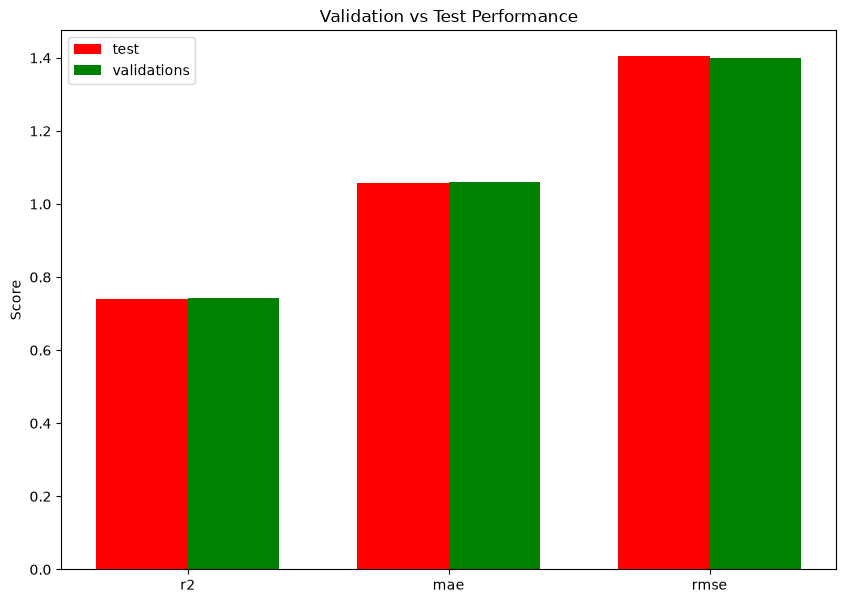

In [55]:
metrics = ["r2","mae","rmse"]
test =[0.7411, 1.057,1.4050]
validations =[0.7426,1.061,1.3992]


x = np.arange(len(metrics))
width = 0.35


import matplotlib.pyplot as plt

plt.figure (figsize= (10, 7))

plt.bar(x - width/2, test, width, color= 'r',  label = "test")
plt.bar(x + width/2, validations, width, color= 'g', label="validations")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Validation vs Test Performance")
plt.legend()
plt.show()


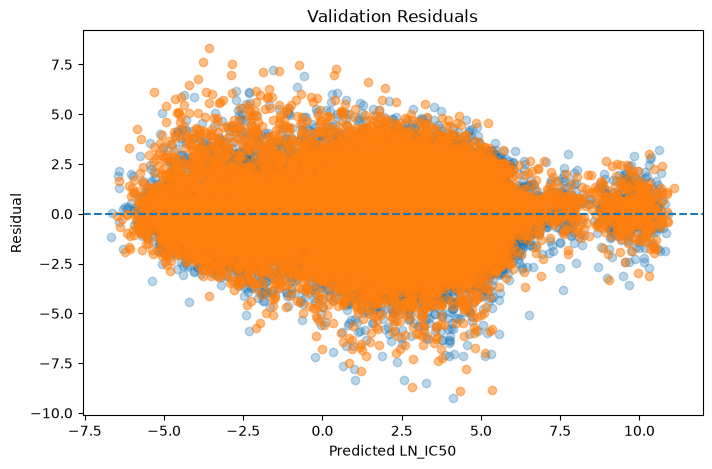

In [58]:
valid_residuals = y_validations - y_valid_pred
test_residuals = y_test - y_test_pred

plt.figure(figsize=(8, 5))

plt.scatter(y_valid_pred, valid_residuals, alpha=0.3)
plt.scatter(y_test_pred, test_residuals, alpha=0.5)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted LN_IC50")
plt.ylabel("Residual")
plt.title("Validation Residuals")

plt.show()

In [60]:
import pickle

with open("XGboost_LN-IC50_cancer_drug_prediction.sav", "wb") as file:
    pickle.dump(best_XG, file)

building recomendation system by finding top 20 drugs relevant pharmakokentics values from FDA, Drug bank, and other sources. 

In [ ]:
conn= sqlite3.connect("cell_passport_database.db")

data_ML_features= pd.read_sql_query("select * from data_ML_features", 
                                    conn)

# print(data_ML_features.head(2))


print(data_ML_features["DRUG_NAME"].value_counts().sort_values(ascending=False).head(20))


DRUG_NAME
Ulixertinib       1698
Oxaliplatin       1684
Fulvestrant       1680
Selumetinib       1666
Dactinomycin      1659
Docetaxel         1637
Uprosertib        1634
GSK343            1634
Acetalax          1434
MG-132             969
Camptothecin       968
Staurosporine      968
Nutlin-3a (-)      968
MK-2206            968
Palbociclib        968
PD0325901          968
5-Fluorouracil     968
Navitoclax         967
Olaparib           967
PD173074           967
Name: count, dtype: int64


In [23]:
top_20 = data_ML_features["DRUG_NAME"].value_counts().sort_values(ascending=False).head(20).index
train_drugs=[]
test_drugs=[]
validations_drugs=[]
for drug in top_20:
  if drug in x_train["DRUG_NAME"].values:
    train_drugs.append(drug)
  if drug in x_test["DRUG_NAME"].values:
     test_drugs.append(drug)
  if drug in x_validations["DRUG_NAME"].values:
     validations_drugs.append(drug)

print("Train:", train_drugs)
print("Test:", test_drugs)
print("Validation:", validations_drugs)

Train: ['Ulixertinib', 'Oxaliplatin', 'Fulvestrant', 'Selumetinib', 'Dactinomycin', 'Docetaxel', 'Uprosertib', 'GSK343', 'Acetalax', 'MG-132', 'Camptothecin', 'Staurosporine', 'Nutlin-3a (-)', 'MK-2206', 'Palbociclib', 'PD0325901', '5-Fluorouracil', 'Navitoclax', 'Olaparib', 'PD173074']
Test: ['Ulixertinib', 'Oxaliplatin', 'Fulvestrant', 'Selumetinib', 'Dactinomycin', 'Docetaxel', 'Uprosertib', 'GSK343', 'Acetalax', 'MG-132', 'Camptothecin', 'Staurosporine', 'Nutlin-3a (-)', 'MK-2206', 'Palbociclib', 'PD0325901', '5-Fluorouracil', 'Navitoclax', 'Olaparib', 'PD173074']
Validation: ['Ulixertinib', 'Oxaliplatin', 'Fulvestrant', 'Selumetinib', 'Dactinomycin', 'Docetaxel', 'Uprosertib', 'GSK343', 'Acetalax', 'MG-132', 'Camptothecin', 'Staurosporine', 'Nutlin-3a (-)', 'MK-2206', 'Palbociclib', 'PD0325901', '5-Fluorouracil', 'Navitoclax', 'Olaparib', 'PD173074']


In [17]:
for drug in top_20:
    train_n = (x_train["DRUG_NAME"] == drug).sum()
    test_n = (x_test["DRUG_NAME"] == drug).sum()
    valid_n = (x_validations["DRUG_NAME"] == drug).sum()

    print(f"{drug:20s} Train: {train_n:5d} | Validation: {valid_n:5d} | Test: {test_n:5d}")

Ulixertinib          Train:  1193 | Validation:   250 | Test:   255
Oxaliplatin          Train:  1182 | Validation:   250 | Test:   252
Fulvestrant          Train:  1180 | Validation:   248 | Test:   252
Selumetinib          Train:  1170 | Validation:   248 | Test:   248
Dactinomycin         Train:  1164 | Validation:   245 | Test:   250
Docetaxel            Train:  1148 | Validation:   239 | Test:   250
Uprosertib           Train:  1148 | Validation:   241 | Test:   245
GSK343               Train:  1148 | Validation:   243 | Test:   243
Acetalax             Train:  1008 | Validation:   212 | Test:   214
MG-132               Train:   678 | Validation:   145 | Test:   146
Camptothecin         Train:   678 | Validation:   145 | Test:   145
Staurosporine        Train:   678 | Validation:   144 | Test:   146
Nutlin-3a (-)        Train:   678 | Validation:   144 | Test:   146
MK-2206              Train:   678 | Validation:   144 | Test:   146
Palbociclib          Train:   678 | Validation: 

In [39]:
reference_drug = pd.read_csv("C:/Users/e_bab/Documents/4geeks/final_project/sanger project/20 drugs Pk.csv")
print(drug.shape)

print(reference_drug.shape)

print(reference_drug.head(5))

print(reference_drug["Name"])

reference_drug.loc[
    reference_drug["Name"].isin(["Fulvestrant", "Selumetinib"]),
    "Name"
].map(repr)

(20, 11)
(20, 11)
                    Name                  dose route  Clinical_status   Cmax  \
0  Ulixertinib                      600 mg BID  Oral  Investigational   2.12   
1     Oxaliplatin                     85 mg/m²    IV         Approved  0.814   
2            Fulvestrant  500 mg + day-15 dose    IM         Approved     28   
3            Selumetinib                 75 mg  Oral         Approved  1,520   
4  Dactinomycin                         500 µg    IV         Approved   99.2   

  Cmax_unit MW(g/mole)    Cmax_M     AUC  AUC_unit FDA_Approved  
0     µg/mL      433.3  4.89E-06   19.93   µg·h/mL          yes  
1     µg/mL     397.29  2.05E-06   8.83*  µg·h/mL*          yes  
2     ng/mL      606.8  4.61E-08  13,100   ng·h/mL          yes  
3     ng/mL      457.7  3.32E-06   4,510   ng·h/mL          yes  
4     ng/mL   1,255.40  7.90E-08     4.9  mg/L·min          yes  
0     Ulixertinib          
1        Oxaliplatin       
2               Fulvestrant
3               Selum

2    'Fulvestrant'
3    'Selumetinib'
Name: Name, dtype: str

In [40]:
reference_drug["Cmax_M"] = pd.to_numeric(
    reference_drug["Cmax_M"],
    errors="coerce"
)

print(reference_drug[["Name", "Cmax_M"]])
print(reference_drug["Cmax_M"].dtype)


                     Name        Cmax_M
0   Ulixertinib            4.890000e-06
1      Oxaliplatin         2.050000e-06
2             Fulvestrant  4.610000e-08
3             Selumetinib  3.320000e-06
4   Dactinomycin           7.900000e-08
5   Docetaxel              2.980000e-06
6   Uprosertib             9.530000e-07
7   GSK343                 4.700000e-06
8   Acetalax                        NaN
9   MG-132                          NaN
10  Camptothecin           6.110000e-05
11   Staurosporine                  NaN
12   Nutlin-3a (-)         2.080000e-05
13  MK-2206                2.770000e-07
14  Palbociclib            4.150000e-07
15   PD0325901             3.150000e-07
16  5-Fluorouracil                  NaN
17    Navitoclax           3.800000e-06
18   Olaparib              1.770000e-05
19   PD173074                       NaN
float64


In [ ]:
from pickle import load
with open("XGboost_LN-IC50_cancer_drug_prediction.sav", "rb") as file:
    model = load (file )


conn= sqlite3.connect("cell_passport_database.db")

x_test_num.to_sql("x_test_num",
                  conn, 
                  if_exists="replace",
                  index=False)

x_test_num = pd.read_sql_query("select * from x_test_num", 
                               conn)

y_test_pred= model.predict(x_test_num)
print(y_test_pred)

ic50_molar =  np.exp(y_test_pred)* 1e-6
print(ic50_molar)

reference_drug.to_sql("reference_drug",
                  conn, 
                  if_exists="replace",
                  index=False)

[-2.9661453 -4.582952   2.2096403 ...  8.84251    7.4340534  9.673511 ]
[5.1501445e-08 1.0224669e-08 9.1124375e-06 ... 6.9223475e-03 1.6926547e-03
 1.5891038e-02]


20

In [18]:
x_train_num.to_sql("x_train_num",
                   conn, 
                   if_exists="replace",
                   index= False)
x_validations_num.to_sql("x_validations_num",
                   conn,
                   if_exists="replace",
                index= False)
x_train_num=pd.read_sql_query("select * from x_train_num", 
                                conn,)

In [21]:
print(x_train_num.columns.tolist())
print(x_train_num.shape)
print(x_train_num.dtypes.value_counts())

['TP53_mutated', 'TP53_mutation_count', 'TP53_min_VAF', 'TP53_max_VAF', 'KRAS_mutated', 'KRAS_mutation_count', 'KRAS_min_VAF', 'KRAS_max_VAF', 'KMT2C_mutated', 'KMT2C_mutation_count', 'KMT2C_min_VAF', 'KMT2C_max_VAF', 'PTEN_mutated', 'PTEN_mutation_count', 'PTEN_min_VAF', 'PTEN_max_VAF', 'KMT2D_mutated', 'KMT2D_mutation_count', 'KMT2D_min_VAF', 'KMT2D_max_VAF', 'RB1_mutated', 'RB1_mutation_count', 'RB1_min_VAF', 'RB1_max_VAF', 'TP53_expression', 'KRAS_expression', 'KMT2C_expression', 'PTEN_expression', 'KMT2D_expression', 'RB1_expression', 'MIN_CONC', 'MAX_CONC', 'ethnicity_Arabic', 'ethnicity_Black', 'ethnicity_East Asian', 'ethnicity_Other', 'ethnicity_South Asian', 'ethnicity_Unknown', 'ethnicity_White', 'gender_Female', 'gender_Male', 'gender_Unknown', 'DRUG_NAME_123138', 'DRUG_NAME_123829', 'DRUG_NAME_150412', 'DRUG_NAME_5-Fluorouracil', 'DRUG_NAME_5-azacytidine', 'DRUG_NAME_50869', 'DRUG_NAME_615590', 'DRUG_NAME_630600', 'DRUG_NAME_667880', 'DRUG_NAME_720427', 'DRUG_NAME_729189',

In [23]:
feature_columns = x_train_num.columns.tolist()

print(len(feature_columns))
with open("feature_columns.pkl", "wb") as file:
    pickle.dump(feature_columns, file)

352


In [ ]:
conn= sqlite3.connect("cell_passport_database.db")
x_train.to_sql("x_train",
                   conn,
                   if_exists="replace",
                   index= False)
x_validations.to_sql("x_validations",
                   conn,if_exists="replace",
                   index= False)



35945

In [66]:

print(repr(reference_drug.loc[1, "Name"]))
print(repr("Oxaliplatin"))
print("Oxaliplatin" in reference_drug)

'Oxaliplatin'
'Oxaliplatin'
False


In [ ]:
# wriritng a function for recomndation system

# conversion functions for LNIC50 
def conversion(LN_IC50):
    ic50_molar =  np.exp(LN_IC50)* 1e-6
    print(f"Predicted IC50: {ic50_molar:.3e} M")
    return  ic50_molar


# recomnedation functions
# Reference_drug_names =["Oxaliplatin","Fulvestrant","Selumetinib","Dactinomycin","Docetaxel","Uprosertib","GSK343","Acetalax","MG-132", "Camptothecin", "Staurosporine", "Nutlin-3a (-)","MK-2206","Palbociclib","PD0325901","5-Fluorouracil","Navitoclax","Olaparib","PD173074"]

Reference_drug_names = reference_drug.loc[
    reference_drug["Cmax_M"].notna(),
    "Name"
].tolist()

def Reference_IC50 (LN_IC50, drug_name):
    drug_name = drug_name.strip()
    if drug_name not in Reference_drug_names:
        print("No clinical Cmax available for this drug.")
        print("Cmax-based comparison cannot be performed.")
        return

    # Get Cmax for the specific drug
    cmax = reference_drug.loc[
        reference_drug["Name"] == drug_name,
        "Cmax_M"
    ].iloc[0]

    predicted_IC50 = conversion(LN_IC50)
    if predicted_IC50 < cmax:
        fold = cmax / predicted_IC50
        print(f"Clinical Cmax is {fold:.1f}× higher than predicted concentration associated with 50% inhibition in the in vitro model.")
    else:
        fold = predicted_IC50 / cmax
        print(f"The predicted concentration associated with 50% inhibition in the invitro model is {fold:.1f}× higher than clinical Cmax.")
        print(f" Warning: Predicted IC50 is above the selected concentration range. Consider increasing the maximum concentration if you want the prediction to cover the predicted IC50.")







In [77]:
Reference_IC50(-1.9661453,"Palbociclib")

Predicted IC50: 1.400e-07 M
The IC50 concentration is within the range of clinical Cmax.


In [ ]:
# adding one exampel to csv tempelate

import pandas as pd

data = {
    "patient_id": ["example_patient"],
    "DRUG_NAME": ["Ulixertinib"],
    "ethnicity": ["White"],
    "gender": ["Female"],
    "TP53_mutated": [1],
    "TP53_mutation_count": [1],
    "TP53_min_VAF": [0.35],
    "TP53_max_VAF": [0.35],
    "TP53_expression": [8.5],

    "KRAS_mutated": [0],
    "KRAS_mutation_count": [0],
    "KRAS_min_VAF": [0],
    "KRAS_max_VAF": [0],
    "KRAS_expression": [7.2],

    "KMT2C_mutated": [0],
    "KMT2C_mutation_count": [0],
    "KMT2C_min_VAF": [0],
    "KMT2C_max_VAF": [0],
    "KMT2C_expression": [6.8],

    "PTEN_mutated": [0],
    "PTEN_mutation_count": [0],
    "PTEN_min_VAF": [0],
    "PTEN_max_VAF": [0],
    "PTEN_expression": [5.4],

    "KMT2D_mutated": [0],
    "KMT2D_mutation_count": [0],
    "KMT2D_min_VAF": [0],
    "KMT2D_max_VAF": [0],
    "KMT2D_expression": [7.1],

    "RB1_mutated": [0],
    "RB1_mutation_count": [0],
    "RB1_min_VAF": [0],
    "RB1_max_VAF": [0],
    "RB1_expression": [6.5],

    "MIN_CONC": [0.0001],
    "MAX_CONC": [0.1]
}

df = pd.DataFrame(data)

df.to_csv("patient_input_template.csv", index=False)